# Formula 1 Podium Prediction — Milestone 1

**Task:** for every driver in a race, predict whether they finish on the podium (`positionOrder <= 3`),
using only information available **after qualifying and before the race starts**.

**Dataset:** Formula 1 World Championship (1950–2024), Kaggle / Ergast — 14 relational CSV tables.

## Table of contents
0. Setup
1. Raw EDA (before cleaning)
2. Data Cleaning & Auditing
3. Post-cleaning EDA
4. Data-Engineering Questions (Q1, Q2, Q3)
5. Feature Selection & Engineering
6. Train / Validation / Test Split
7. Pre-processing (incl. preprocessing-order experiments)
8. Predictive Modeling (baseline, statistical models, shallow NN)
9. Feature-Group Ablation
10. Explainability (XAI)
11. Inference Function
12. Summary & Limitations

# 0. Setup

This section makes the notebook reproducible and **Run-All ready**:
- imports and library versions (so results can be reproduced),
- one global random seed,
- project-wide constants (target, split boundaries),
- loading all 14 raw tables into an **immutable** `raw` dictionary — all cleaning later happens on copies,
- primary/foreign key definitions used by the audit in Section 2.

## 0.1 Optional installs
`lime` is not always pre-installed on Kaggle. On Kaggle, turn **Internet ON** in the notebook settings for this cell to work.
The cell is safe to re-run: it only installs what is missing.

In [1]:
import importlib.util, subprocess, sys

for pkg in ["shap", "lime"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
    else:
        print(f"{pkg} already installed")

shap already installed
lime already installed


## 0.2 Imports and versions

In [2]:
import os
import sys
import importlib
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

def _version(name):
    try:
        return importlib.import_module(name).__version__
    except Exception:
        return "not installed"

for lib in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn",
            "xgboost", "lightgbm", "tensorflow", "torch", "shap", "lime"]:
    print(f"{lib:<12} {_version(lib)}")
print(f"{'python':<12} {sys.version.split()[0]}")

numpy        2.1.3
pandas       2.3.3
matplotlib   3.10.0
seaborn      0.13.2
sklearn      1.6.1
xgboost      3.4.1
lightgbm     4.6.0
tensorflow   2.20.0
torch        2.11.0+cpu
shap         0.52.0
lime         not installed
python       3.13.15


## 0.3 Reproducibility and project constants
All randomness (sampling, model initialisation, NN training) is driven by one seed.
The split boundaries are temporal (justified in Section 6): training on the past, evaluating on the future,
which mirrors how the model would be used in practice.

In [3]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass
    try:
        import torch
        torch.manual_seed(seed)
    except ImportError:
        pass

set_seed()

# Target definition
TARGET = "podium"           # 1 if positionOrder <= 3 else 0
PODIUM_CUTOFF = 3

# Temporal split boundaries (seasons, inclusive)
TRAIN_END = 2019
VAL_YEARS = (2020, 2021)
TEST_START = 2022

# Era boundaries used in the data-engineering questions
HYBRID_ERA = (2014, 2021)
GROUND_EFFECT_ERA = (2022, 2024)

# Sentinel used for missing values in the raw CSVs (handled in Section 2)
SENTINEL = r"\N"

## 0.4 Locate the data
Finds the dataset automatically on Kaggle (`/kaggle/input/...`) or in a local `data/` folder,
so the same notebook runs in both places without manual edits.

In [4]:
TABLES = [
    "circuits", "constructors", "constructor_results", "constructor_standings",
    "drivers", "driver_standings", "races", "results", "qualifying",
    "lap_times", "pit_stops", "sprint_results", "seasons", "status",
]

def find_data_dir() -> Path:
    candidates = [Path("/kaggle/input"), Path("data"), Path("../data"), Path(".")]
    for root in candidates:
        if not root.exists():
            continue
        for hit in root.rglob("circuits.csv"):
            return hit.parent
    raise FileNotFoundError(
        "Could not find the F1 CSVs. On Kaggle, add the dataset via 'Add Input'; "
        "locally, place the 14 CSV files in a 'data/' folder."
    )

DATA_DIR = find_data_dir()
print("Data directory:", DATA_DIR)

missing_files = [t for t in TABLES if not (DATA_DIR / f"{t}.csv").exists()]
assert not missing_files, f"Missing tables: {missing_files}"
print(f"All {len(TABLES)} tables found.")

Data directory: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
All 14 tables found.


## 0.5 Load raw tables (immutable)
The raw tables are loaded **as-is**: the `\N` sentinel is deliberately kept as a string here,
so the raw EDA in Section 1 can measure how much of it exists before we clean it.

To guarantee the raw data is never modified, each table gets a fingerprint (hash) at load time.
`get_table()` always returns a copy, and `assert_raw_unchanged()` can be called at any point to prove the raw data is intact.

In [5]:
raw = {t: pd.read_csv(DATA_DIR / f"{t}.csv", keep_default_na=False, na_values=[""])
       for t in TABLES}

def fingerprint(df: pd.DataFrame) -> str:
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values.tobytes()).hexdigest()

RAW_FINGERPRINTS = {t: fingerprint(df) for t, df in raw.items()}

def get_table(name: str) -> pd.DataFrame:
    # Always work on a copy so the raw tables stay untouched.
    return raw[name].copy()

def assert_raw_unchanged() -> None:
    changed = [t for t, df in raw.items() if fingerprint(df) != RAW_FINGERPRINTS[t]]
    assert not changed, f"Raw tables were modified: {changed}"
    print("Raw tables unchanged ✔")

assert_raw_unchanged()

Raw tables unchanged ✔


## 0.6 Load sanity check
A first look at what was loaded: size of each table, how many `\N` sentinels it contains,
and which seasons the data covers. Detailed EDA follows in Section 1.

In [6]:
def count_sentinels(df: pd.DataFrame) -> int:
    return int((df.astype(str) == SENTINEL).sum().sum())

overview = pd.DataFrame({
    "rows": {t: len(df) for t, df in raw.items()},
    "columns": {t: df.shape[1] for t, df in raw.items()},
    "sentinel_cells": {t: count_sentinels(df) for t, df in raw.items()},
}).sort_values("rows", ascending=False)
overview["sentinel_%"] = (100 * overview["sentinel_cells"]
                          / (overview["rows"] * overview["columns"])).round(2)
display(overview)

years = raw["races"]["year"]
print(f"Seasons covered: {years.min()}–{years.max()}  ({years.nunique()} seasons, {len(raw['races'])} races)")
results_years = raw["results"].merge(raw["races"][["raceId", "year"]], on="raceId")["year"]
print(f"Seasons with results: {results_years.min()}–{results_years.max()}")

,rows,columns,sentinel_cells,sentinel_%
lap_times,589081,6,0,0.00
driver_standings,34863,7,0,0.00
results,26759,18,122887,25.51
constructor_standings,13391,7,0,0.00
constructor_results,12625,5,12608,19.97
pit_stops,11371,7,0,0.00
qualifying,10494,9,11600,12.28
races,1125,18,11349,56.04
drivers,861,9,1559,20.12
sprint_results,360,16,73,1.27


Seasons covered: 1950–2024  (75 seasons, 1125 races)
Seasons with results: 1950–2024


In [7]:
for t in TABLES:
    print(f"{t:<22} {list(raw[t].columns)}")

circuits               ['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']
constructors           ['constructorId', 'constructorRef', 'name', 'nationality', 'url']
constructor_results    ['constructorResultsId', 'raceId', 'constructorId', 'points', 'status']
constructor_standings  ['constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', 'positionText', 'wins']
drivers                ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']
driver_standings       ['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']
races                  ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
results                ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'posi

## 0.7 Key definitions (used by the audit in Section 2)
Primary keys identify each row; foreign keys must point to an existing primary key in the referenced table.
Defining them once here keeps the audit in Section 2 short and consistent.
Composite keys (e.g. `lap_times`) are tables whose rows are only unique for a combination of columns.

In [8]:
PRIMARY_KEYS = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "qualifying": ["qualifyId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "sprint_results": ["resultId"],
    "seasons": ["year"],
    "status": ["statusId"],
}

# (child table, child column, parent table, parent column)
FOREIGN_KEYS = [
    ("races", "circuitId", "circuits", "circuitId"),
    ("races", "year", "seasons", "year"),
    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),
    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId"),
    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),
    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),
    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),
    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),
    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),
]

# Sanity check: every key column actually exists in the loaded tables
for t, cols in PRIMARY_KEYS.items():
    assert set(cols) <= set(raw[t].columns), f"PK columns missing in {t}: {cols}"
for child, ccol, parent, pcol in FOREIGN_KEYS:
    assert ccol in raw[child].columns and pcol in raw[parent].columns, (child, ccol, parent, pcol)
print(f"{len(PRIMARY_KEYS)} primary keys and {len(FOREIGN_KEYS)} foreign keys defined ✔")

14 primary keys and 23 foreign keys defined ✔


## 0.8 Columns that must never be features (leakage guard)
These columns are only known **after** the race. They are listed here once so later sections can assert
that none of them ends up in the feature matrix. The full leakage audit (with reasons per column) is in Section 5.

In [9]:
POST_RACE_COLUMNS = {
    # results.csv
    "position", "positionText", "positionOrder", "points", "laps", "time",
    "milliseconds", "fastestLap", "rank", "fastestLapTime", "fastestLapSpeed", "statusId",
    # derived target
    TARGET,
}
POST_RACE_TABLES = {"lap_times", "pit_stops"}   # current-race data, never features
# Standings tables are post-race *for the current race*; they are only usable after shifting
# to "standings before this race" (done in Section 5).

def assert_no_leakage(feature_columns) -> None:
    leaked = set(feature_columns) & POST_RACE_COLUMNS
    assert not leaked, f"Post-race columns in features: {sorted(leaked)}"
    print("No post-race columns in features ✔")

# 1. Raw EDA (before cleaning)

**Goal:** measure every data-quality problem *before* changing anything, so each cleaning rule in Section 2
is backed by evidence rather than manual inspection.

**Rules for this section**
- Read only: every table comes from `raw` or `get_table()` (a copy). Nothing is cleaned here.
- Where a measurement needs numbers (e.g. `grid`), the column is converted *temporarily inside the cell*.
- Each subsection ends with a **Finding → Decision** note that links the evidence to a step in Section 2.

## 1.0 Plot style and reusable helpers

In [10]:
# --- Plot style ---------------------------------------------------------------
# One consistent look for every figure in the notebook: a fixed, colour-blind-safe
# colour order, thin lines, a light grid and no top/right frame.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
})

In [11]:
# --- Reusable EDA helpers -------------------------------------------------------
# Defined once and used both before cleaning (Section 1) and after it (Section 3),
# so the before/after comparison uses exactly the same measurements.

def to_num(s):
    # Temporary numeric view of a column, for measuring only (does not clean anything).
    return pd.to_numeric(s, errors="coerce")

def is_missing(s):
    # A cell counts as missing if it is NaN/empty OR the literal sentinel "\N".
    return s.isna() | (s.astype(str) == SENTINEL)

def missing_profile(tables):
    # One row per (table, column): number and % of missing cells.
    rows = []
    for t, df in tables.items():
        for c in df.columns:
            m = is_missing(df[c])
            rows.append({"table": t, "column": c, "rows": len(df),
                         "missing": int(m.sum()), "missing_%": 100 * m.mean()})
    return pd.DataFrame(rows)

def with_year(df, races_df):
    # Attaches the season (and race name) to any table that has a raceId column.
    return df.merge(races_df[["raceId", "year", "name"]], on="raceId", how="left")

In [12]:
# --- Raw results with season and status text attached ----------------------------
# Most raw-EDA questions are about results, so this joined copy is built once
# and reused in the cells below.
res_raw = (with_year(get_table("results"), raw["races"])
           .merge(raw["status"], on="statusId", how="left"))
res_raw.shape

(26759, 21)

## 1.1 Where are values missing?
Cell 0.6 counted only the `\N` sentinel. Here we count **both** `\N` and truly empty cells, per column.

In [13]:
# --- Missing values per column (raw) ------------------------------------------
raw_missing = missing_profile(raw)
raw_missing_nonzero = (raw_missing[raw_missing["missing"] > 0]
                       .sort_values("missing_%", ascending=False)
                       .reset_index(drop=True))
print(f"{len(raw_missing_nonzero)} of {len(raw_missing)} columns contain missing values.")
display(raw_missing_nonzero.round(2))

30 of 120 columns contain missing values.


,table,column,rows,missing,missing_%
0,constructor_results,status,12625,12608,99.87
1,races,sprint_time,1125,1110,98.67
2,races,sprint_date,1125,1107,98.40
3,races,fp3_time,1125,1072,95.29
4,races,fp2_time,1125,1057,93.96
5,races,fp1_time,1125,1057,93.96
6,races,quali_time,1125,1057,93.96
7,races,fp3_date,1125,1053,93.60
8,drivers,number,861,802,93.15
9,races,fp1_date,1125,1035,92.00


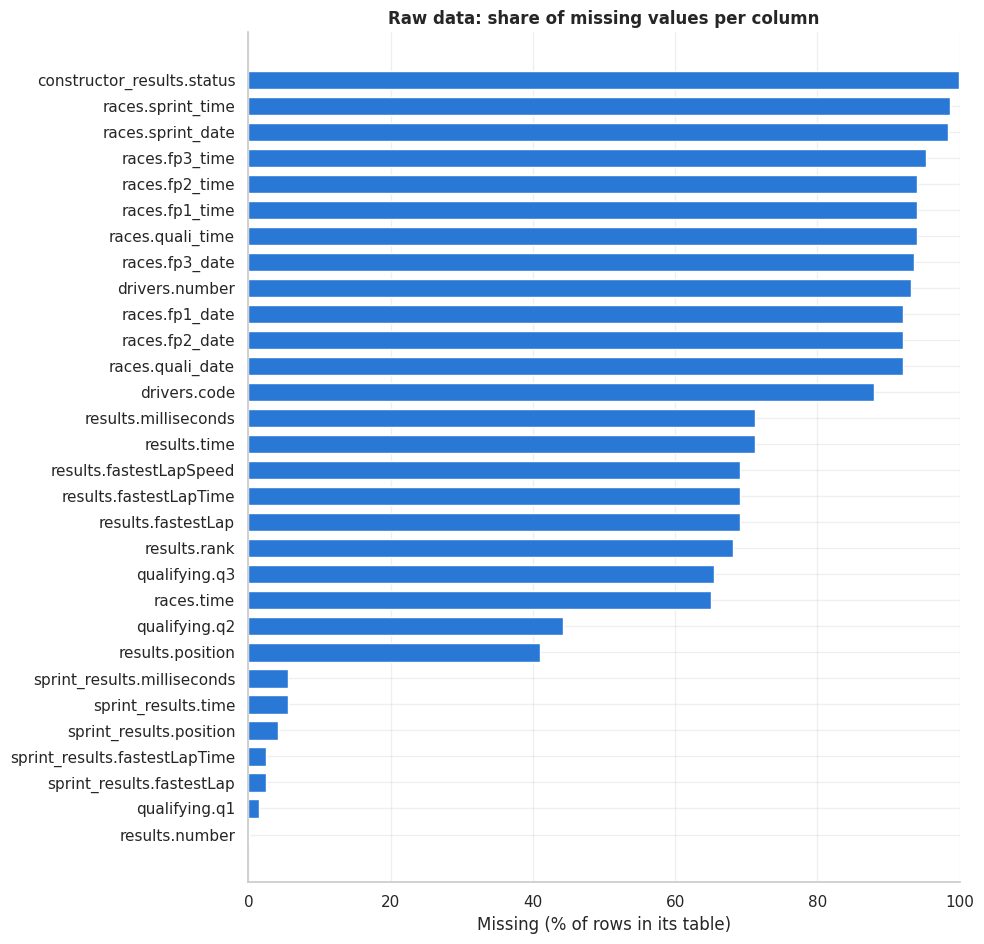

In [14]:
# --- Plot: missing % per column ---------------------------------------------------
# One bar per column (table.column); only columns with at least one missing value.
plot_df = raw_missing_nonzero.assign(label=lambda d: d["table"] + "." + d["column"])

fig, ax = plt.subplots(figsize=(10, 0.28 * len(plot_df) + 1.2))
ax.barh(plot_df["label"], plot_df["missing_%"], color=PALETTE[0], height=0.7)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Missing (% of rows in its table)")
ax.set_title("Raw data: share of missing values per column")
plt.tight_layout()
plt.show()

**Finding:** missing values are concentrated in a few places: race outcome and fastest-lap columns in `results`,
the session date/time columns in `races`, `q2`/`q3` in `qualifying`, `number`/`code` in `drivers`,
and `constructor_results.status`, which is almost completely empty.

**Decision:**
- Every `\N` becomes a real missing value (`NaN`) → **2.2**.
- A column that is (almost) entirely empty carries no information → dropped → **2.4**.
- *Why* a value is missing differs per column, so we look at that next before deciding anything else.

## 1.2 Is missingness random, or tied to eras?
If a column's missing share changes with the season, the value was simply **not recorded** in older eras.
If it is roughly constant, it depends on the **race outcome** (e.g. no finishing position for a retirement).

In [15]:
# --- Missing % per season for selected results / races columns -----------------
def missing_by_season(df, col):
    return df.groupby("year")[col].apply(lambda s: is_missing(s).mean() * 100)

races_r = get_table("races")
season_missing = pd.DataFrame({
    "results.position":       missing_by_season(res_raw, "position"),
    "results.milliseconds":   missing_by_season(res_raw, "milliseconds"),
    "results.fastestLapTime": missing_by_season(res_raw, "fastestLapTime"),
    "races.time":             missing_by_season(races_r, "time"),
    "races.fp1_date":         missing_by_season(races_r, "fp1_date"),
})
season_missing.iloc[::10].round(1)   # every 10th season, as a quick look

,results.position,results.milliseconds,results.fastestLapTime,races.time,races.fp1_date
year,,,,,
1950,48.1,90.0,100.0,100.0,100.0
1960,40.8,81.2,100.0,100.0,100.0
1970,54.8,81.6,100.0,100.0,100.0
1980,55.4,83.3,100.0,100.0,100.0
1990,59.6,83.8,100.0,100.0,100.0
2000,38.3,71.6,100.0,100.0,100.0
2010,23.9,53.5,5.9,0.0,100.0
2020,15.6,43.8,3.5,0.0,100.0


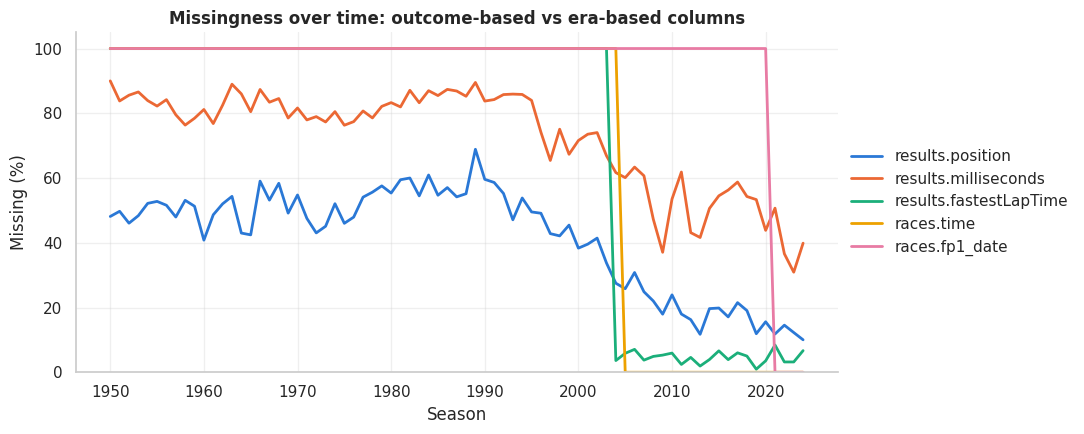

In [16]:
# --- Plot: missing % per season ------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
season_missing.plot(ax=ax)
ax.set_ylim(0, 105)
ax.set_xlabel("Season")
ax.set_ylabel("Missing (%)")
ax.set_title("Missingness over time: outcome-based vs era-based columns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout()
plt.show()

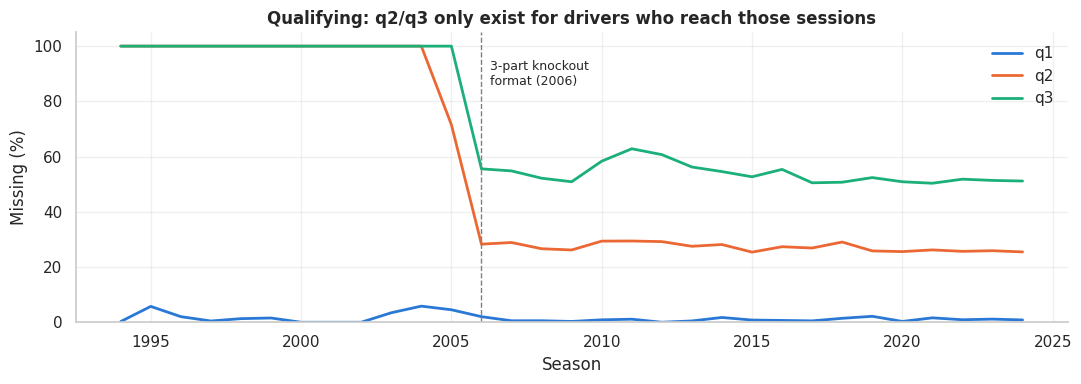

In [17]:
# --- Qualifying: missing % of q1/q2/q3 per season ------------------------------------
# Only seasons that have qualifying rows at all appear here (coverage is 1.3).
qual_raw = with_year(get_table("qualifying"), raw["races"])
qual_missing = qual_raw.groupby("year")[["q1", "q2", "q3"]].agg(lambda s: is_missing(s).mean() * 100)

fig, ax = plt.subplots(figsize=(11, 4))
qual_missing.plot(ax=ax)
ax.axvline(2006, color="grey", ls="--", lw=1)
ax.text(2006.3, 95, "3-part knockout\nformat (2006)", fontsize=9, va="top")
ax.set_ylim(0, 105)
ax.set_xlabel("Season")
ax.set_ylabel("Missing (%)")
ax.set_title("Qualifying: q2/q3 only exist for drivers who reach those sessions")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Finding:** there are three different *kinds* of missingness:

| Kind | Columns | Meaning |
|---|---|---|
| Outcome-based | `results.position`, `results.milliseconds` | Driver was not classified / did not finish. Roughly stable across eras. |
| Era-based | `results.fastestLapTime`, `races.time`, `races.fp1_date` (and other session columns) | Not recorded in older seasons: 100 % missing until a certain year, then filled. |
| Structural | `qualifying.q2`, `qualifying.q3` | The session did not exist for that driver (knocked out earlier) or for that era (before 2006). |

**Decision:** all three become `NaN` in cleaning, but **no imputation happens in cleaning**. Filling a value is
a modeling choice that depends on its meaning (e.g. a missing `q3` means "slower than Q3", not "unknown"),
so it is left to the preprocessing step (Phase 7) and the meaning is documented in the handover (2.8).
The outcome-based columns are post-race and will never be features anyway.

## 1.3 Missing rows, not just missing cells
`lap_times` and `pit_stops` showed **0 %** sentinels in cell 0.6, yet they don't cover every race.
Their missingness is **absent rows**, which cell counts cannot see. We measure it as: for each season, the share of
`results` rows that have at least one matching row in the other table.

In [18]:
# --- Coverage of qualifying / lap_times / pit_stops per season --------------------
def coverage_by_season(base, other, keys=("raceId", "driverId")):
    # % of base rows (per season) that have a matching row in `other`.
    keys = list(keys)
    hits = other[keys].drop_duplicates().assign(_hit=True)
    has = base[keys + ["year"]].merge(hits, on=keys, how="left")["_hit"].notna()
    return has.groupby(base["year"].values).mean() * 100

coverage = pd.DataFrame({
    "qualifying": coverage_by_season(res_raw, raw["qualifying"]),
    "lap_times":  coverage_by_season(res_raw, raw["lap_times"]),
    "pit_stops":  coverage_by_season(res_raw, raw["pit_stops"]),
})
first_year = coverage.apply(lambda s: s[s > 0].index.min())
print("First season with any coverage:")
print(first_year.to_string())

First season with any coverage:
qualifying    1994
lap_times     1996
pit_stops     2011


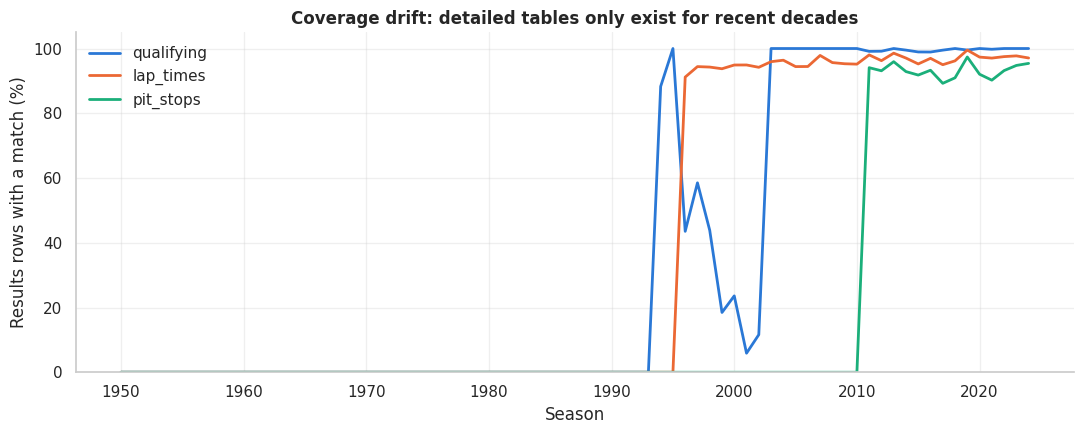

In [19]:
# --- Plot: coverage per season ------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
coverage.plot(ax=ax)
ax.set_ylim(0, 105)
ax.set_xlabel("Season")
ax.set_ylabel("Results rows with a match (%)")
ax.set_title("Coverage drift: detailed tables only exist for recent decades")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Finding:** `qualifying`, `lap_times` and `pit_stops` have **zero** coverage before the first seasons printed above.
In earlier seasons the starting order is only known from `results.grid`. Coverage is also **not complete after it starts**:
qualifying has a deep dip in the late 1990s / early 2000s (many races in those seasons have no qualifying rows at all;
read the exact seasons from the plot), and only becomes near-complete from the early 2000s.

**Decision:** this is not something cleaning can fix (the data does not exist). It is handed over to the
features/modeling owner: qualifying-based features only exist from the mid-1990s, so they must either fall back to
`grid`, use a missing-indicator, or restrict the training window. This is the *qualifying-coverage drift* the brief mentions.

## 1.4 Are columns stored as the right type?
Every text column is reduced to the *shape* of its values (each digit → `9`), e.g. `"1:27.452"` → `9:99.999`.
The shapes tell us which columns are dates, clock times, durations, or numbers stored as text.

In [20]:
# --- Value shapes of every text column -------------------------------------------------
def value_shapes(s):
    v = s[~is_missing(s)].astype(str)
    return v.str.replace(r"\d", "9", regex=True).value_counts()

rows = []
for t, df in raw.items():
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            continue                               # already numeric
        shapes = value_shapes(df[c])
        rows.append({"table": t, "column": c, "dtype": str(df[c].dtype),
                     "distinct_shapes": len(shapes),
                     "top_shapes": ", ".join(shapes.index[:4]) if len(shapes) <= 10 else "(free text)"})
type_audit = pd.DataFrame(rows)
display(type_audit[type_audit["top_shapes"] != "(free text)"].reset_index(drop=True))

,table,column,dtype,distinct_shapes,top_shapes
0,constructor_results,status,object,1,D
1,constructor_standings,positionText,object,3,"9, 99, E"
2,drivers,number,object,2,"99, 9"
3,drivers,dob,object,1,9999-99-99
4,driver_standings,positionText,object,4,"99, 9, 999, D"
5,races,date,object,1,9999-99-99
6,races,time,object,1,99:99:99
7,races,fp1_date,object,1,9999-99-99
8,races,fp1_time,object,1,99:99:99
9,races,fp2_date,object,1,9999-99-99


In [21]:
# --- results.time mixes two different quantities -------------------------------------
# The winner's row holds the total race time; everyone else holds a gap ("+5.478")
# or a lap count. One column, two meanings -> cannot become one number.
t = res_raw["time"][~is_missing(res_raw["time"])]
print("Gap to winner ('+...'):", int(t.str.startswith("+").sum()))
print("Total race time       :", int((~t.str.startswith("+")).sum()))
display(t.sample(6, random_state=SEED).to_frame())

Gap to winner ('+...'): 6552
Total race time       : 1128


,time
23717,1:36:26.552
20520,+36.299
4645,+29.896
21281,+30.483
15595,1:41:45.354
3372,+54.009


**Finding:** the shapes give a clear conversion plan:

| Semantic type | Shape(s) | Columns | Target type |
|---|---|---|---|
| Date | `9999-99-99` | `races.date`, `races.*_date`, `drivers.dob` | `datetime64` |
| Clock time (time of day) | `99:99:99` | `races.time`, `races.*_time`, `pit_stops.time` | `timedelta` (time since midnight) |
| Duration | `9:99.999`, `99.999`, `9:99`, `9:99:99.999` | `qualifying.q1/q2/q3`, `*.fastestLapTime`, `lap_times.time`, `pit_stops.duration` | `float` seconds, in a new `<column>_sec` column |
| Number stored as text | `9`, `99`, `999.999` | e.g. `results.position`, `milliseconds`, `fastestLap`, `rank`, `drivers.number` | numeric |

Durations come in **several formats** (`ss.sss`, `m:ss.sss`, `mm:ss.sss`, `h:mm:ss.sss`, and `m:ss` without decimals), so the
parser must handle all of them. `results.time` / `sprint_results.time` mix total time and gaps: they are **left as text**,
because they are post-race and their numeric version already exists in `milliseconds`.

**Decision:** → **2.3** (typing), with the duration parser validated against the dataset's own `milliseconds` columns.

## 1.5 Does any driver appear more than once in the same race?
The modeling grain is one row per `(raceId, driverId)`.

In [22]:
# --- Duplicate (raceId, driverId) pairs in results ---------------------------------------
dup_mask_raw = res_raw.duplicated(["raceId", "driverId"], keep=False)
dup_raw = res_raw[dup_mask_raw]
print("Rows involved :", int(dup_mask_raw.sum()))
print("Distinct pairs:", dup_raw.groupby(["raceId", "driverId"]).ngroups)

Rows involved : 176
Distinct pairs: 85


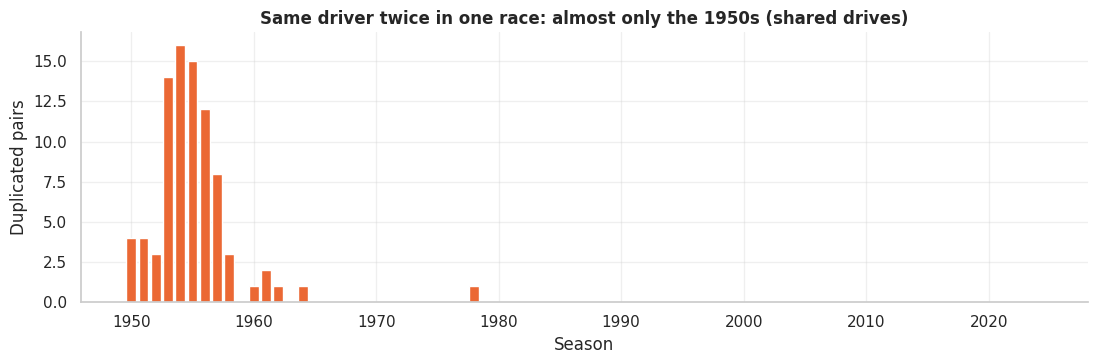

In [23]:
# --- Plot: duplicated pairs per season ----------------------------------------------------
dup_pairs_per_year = (dup_raw.drop_duplicates(["raceId", "driverId"])
                      .groupby("year").size()
                      .reindex(range(1950, 2025), fill_value=0))

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(dup_pairs_per_year.index, dup_pairs_per_year.values, color=PALETTE[1], width=0.8)
ax.set_xlabel("Season")
ax.set_ylabel("Duplicated pairs")
ax.set_title("Same driver twice in one race: almost only the 1950s (shared drives)")
plt.tight_layout()
plt.show()

In [24]:
# --- What duplicates look like --------------------------------------------------------------
# Sorted so each driver's rows for one race sit together.
cols = ["raceId", "year", "name", "driverId", "resultId", "number",
        "grid", "positionText", "positionOrder", "points", "laps", "status"]
display(dup_raw.sort_values(["raceId", "driverId", "resultId"])[cols].head(16))

,raceId,year,name,driverId,resultId,number,grid,positionText,positionOrder,points,laps,status
13188,540,1978,Italian Grand Prix,229,13189,10,0,F,26,0.0,0,Did not qualify
13191,540,1978,Italian Grand Prix,229,13192,23,0,F,29,0.0,0,Did not prequalify
17362,717,1964,United States Grand Prix,373,17363,1,1,7,7,0.0,102,Out of fuel
24298,717,1964,United States Grand Prix,373,24304,2,1,R,12,0.0,54,Injection
17740,733,1962,British Grand Prix,465,17741,48,0,W,22,0.0,0,Withdrew
17743,733,1962,British Grand Prix,465,17744,50,0,W,25,0.0,0,Withdrew
17961,742,1961,British Grand Prix,475,17962,26,20,D,19,0.0,56,Disqualified
17963,742,1961,British Grand Prix,475,17964,28,5,R,21,0.0,44,Brakes
18062,745,1961,United States Grand Prix,418,18063,22,11,R,17,0.0,23,Gearbox
24297,745,1961,United States Grand Prix,418,24303,21,15,11,11,0.0,92,+8 Laps


In [25]:
# --- Same grain check on every table that will be joined on these keys ---------------------
grain_keys = {
    "results":               ["raceId", "driverId"],
    "qualifying":            ["raceId", "driverId"],
    "sprint_results":        ["raceId", "driverId"],
    "driver_standings":      ["raceId", "driverId"],
    "constructor_standings": ["raceId", "constructorId"],
    "constructor_results":   ["raceId", "constructorId"],
}
grain_raw = pd.Series({t: int(raw[t].duplicated(k).sum()) for t, k in grain_keys.items()},
                      name="duplicate key rows")
grain_raw.to_frame()

,duplicate key rows
results,91
qualifying,0
sprint_results,0
driver_standings,0
constructor_standings,0
constructor_results,0


**Finding:** only `results` breaks the grain. The duplicates are almost all in the 1950s, as expected from shared drives,
plus a few cases where the driver had **two entries that never started** (e.g. two "Did not qualify" rows).
The other tables are already unique on their join keys, so joins later will not multiply rows.

**Decision:** non-starter entries are removed first (**2.6**, see 1.7), then a single rule picks one row per remaining pair (**2.7**).

## 1.6 Are primary keys unique and foreign keys valid?
The keys were defined in Section 0.7. These two functions are reused after cleaning (2.5 and 3.x).

In [26]:
# --- Key-audit functions ----------------------------------------------------------------
def pk_audit(tables):
    # Primary key: no duplicates, no missing values.
    rows = []
    for t, k in PRIMARY_KEYS.items():
        df = tables[t]
        rows.append({"table": t, "primary_key": ", ".join(k),
                     "duplicates": int(df.duplicated(k).sum()),
                     "nulls": int(df[k].apply(is_missing).any(axis=1).sum())})
    return pd.DataFrame(rows)

def fk_audit(tables):
    # Foreign key: every (non-missing) value exists in the parent table.
    rows = []
    for child, ccol, parent, pcol in FOREIGN_KEYS:
        c = tables[child][ccol]
        c = c[~is_missing(c)]
        orphans = ~to_num(c).isin(to_num(tables[parent][pcol]))
        rows.append({"foreign_key": f"{child}.{ccol}", "references": f"{parent}.{pcol}",
                     "orphans": int(orphans.sum())})
    return pd.DataFrame(rows)

In [27]:
# --- Primary keys (raw) ------------------------------------------------------------------------
pk_raw = pk_audit(raw)
pk_raw

,table,primary_key,duplicates,nulls
0,circuits,circuitId,0,0
1,constructors,constructorId,0,0
2,constructor_results,constructorResultsId,0,0
3,constructor_standings,constructorStandingsId,0,0
4,drivers,driverId,0,0
5,driver_standings,driverStandingsId,0,0
6,races,raceId,0,0
7,results,resultId,0,0
8,qualifying,qualifyId,0,0
9,lap_times,"raceId, driverId, lap",0,0


In [28]:
# --- Foreign keys (raw) ------------------------------------------------------------------------
fk_raw = fk_audit(raw)
print("Total orphan values:", fk_raw["orphans"].sum())
fk_raw

Total orphan values: 0


,foreign_key,references,orphans
0,races.circuitId,circuits.circuitId,0
1,races.year,seasons.year,0
2,results.raceId,races.raceId,0
3,results.driverId,drivers.driverId,0
4,results.constructorId,constructors.constructorId,0
5,results.statusId,status.statusId,0
6,qualifying.raceId,races.raceId,0
7,qualifying.driverId,drivers.driverId,0
8,qualifying.constructorId,constructors.constructorId,0
9,sprint_results.raceId,races.raceId,0


In [29]:
# --- The reverse direction: parents that are never referenced -----------------------------------
# Not an error, but it explains row counts after joins.
unreferenced = pd.Series({
    "races without results":        int((~raw["races"]["raceId"].isin(raw["results"]["raceId"])).sum()),
    "drivers without results":      int((~raw["drivers"]["driverId"].isin(raw["results"]["driverId"])).sum()),
    "constructors without results": int((~raw["constructors"]["constructorId"].isin(raw["results"]["constructorId"])).sum()),
    "circuits without races":       int((~raw["circuits"]["circuitId"].isin(raw["races"]["circuitId"])).sum()),
}, name="count")
unreferenced.to_frame()

,count
races without results,0
drivers without results,0
constructors without results,1
circuits without races,0


**Finding:** see the two tables above: whether every primary key is unique and non-null, and how many orphan
foreign-key values exist. A few drivers/constructors/circuits are never referenced (e.g. entries that never raced);
this is harmless because all joins go from `results` outward.

**Decision:** the same audit is re-run after typing (**2.5**); any duplicate primary key or orphan found there is removed and logged.

## 1.7 Special values that need a decision
Three things in `results` look like normal data but need a scope decision:
the letter codes in `positionText`, `grid = 0`, and the Indianapolis 500.

In [30]:
# --- positionText letter codes per decade --------------------------------------------------
# Numbers = classified finishing position. Letters: R retired, F failed to qualify,
# W withdrawn, N not classified, D disqualified, E excluded.
code_label = res_raw["positionText"].where(~res_raw["positionText"].str.isdigit(), "classified")
decade = (res_raw["year"] // 10 * 10).astype(str) + "s"
code_by_decade = pd.crosstab(decade, code_label)
code_by_decade = code_by_decade[["classified", "R", "N", "F", "W", "D", "E"]]
code_by_decade

positionText,classified,R,N,F,W,D,E
year,,,,,,,
1950s,1000,903,9,50,39,6,0
1960s,1055,806,35,75,133,9,0
1970s,1873,1457,79,331,42,25,0
1980s,1868,1952,49,545,29,54,6
1990s,2072,1759,8,358,29,22,2
2000s,2543,1041,5,5,27,22,0
2010s,3529,725,5,4,25,8,1
2020s,1868,254,0,0,12,5,0


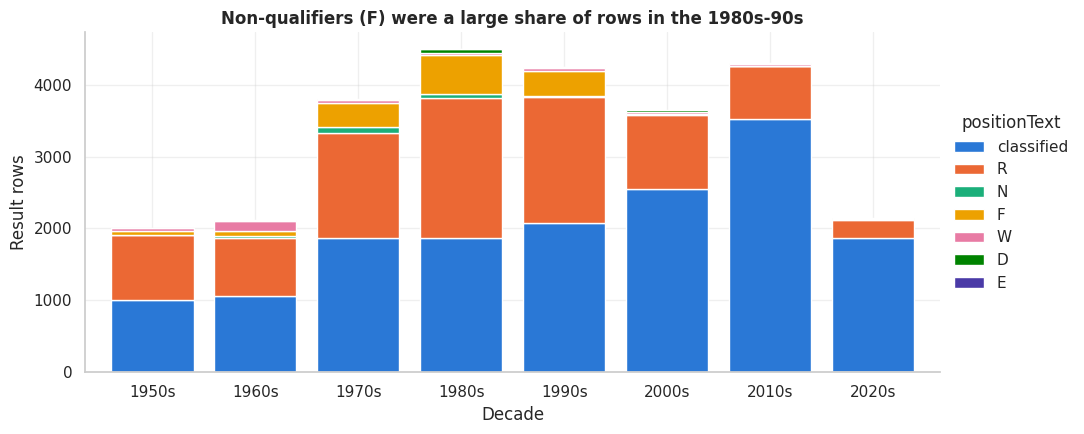

In [31]:
# --- Plot: positionText codes per decade ------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
code_by_decade.plot(kind="bar", stacked=True, ax=ax, width=0.8, edgecolor="white", linewidth=1)
ax.set_xlabel("Decade")
ax.set_ylabel("Result rows")
ax.set_title("Non-qualifiers (F) were a large share of rows in the 1980s-90s")
ax.legend(title="positionText", loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# --- What do F and W rows have in common? ------------------------------------------------------
fw = res_raw[res_raw["positionText"].isin(["F", "W"])]
summary_fw = fw.groupby("positionText").agg(
    rows=("resultId", "size"),
    grid_zero_pct=("grid", lambda s: (s == 0).mean() * 100),
    laps_zero_pct=("laps", lambda s: (s == 0).mean() * 100),
)
display(summary_fw.round(1))
display(fw.groupby("positionText")["status"].value_counts().groupby(level=0).head(4).to_frame())

,rows,grid_zero_pct,laps_zero_pct
positionText,,,
F,1368,98.5,99.9
W,336,60.4,98.5


count
positionText status                   
F            Did not qualify      1025
             Did not prequalify    331
             107% Rule               9
             Injury                  3
W            Withdrew              228
             Accident               29
             Engine                 19
             Gearbox                 8

In [33]:
# --- grid = 0: non-starters or pit-lane starts? -----------------------------------------------
# A driver with laps > 0 actually raced; with laps = 0 they (almost always) never started.
g0 = res_raw[res_raw["grid"] == 0]
grid0_table = pd.crosstab(
    np.where(g0["positionText"].isin(["F", "W"]), "positionText F / W", "other positionText"),
    np.where(g0["laps"] > 0, "laps > 0 (raced, e.g. pit-lane start)", "laps = 0 (did not race)"),
    margins=True)
grid0_table

col_0,laps = 0 (did not race),"laps > 0 (raced, e.g. pit-lane start)",All
row_0,,,
other positionText,15,72,87
positionText F / W,1551,0,1551
All,1566,72,1638


In [34]:
# --- Indianapolis 500: who took part? -------------------------------------------------------------
is_indy_raw = res_raw["name"].eq("Indianapolis 500")
indy_drivers  = set(res_raw.loc[is_indy_raw, "driverId"])
other_drivers = set(res_raw.loc[~is_indy_raw, "driverId"])
print("Indy 500 races   :", res_raw.loc[is_indy_raw, "raceId"].nunique())
print("Indy 500 rows    :", int(is_indy_raw.sum()))
print(f"Indy 500 drivers : {len(indy_drivers)}, of whom only "
      f"{len(indy_drivers & other_drivers)} ever started another championship race")

# The same circuit also hosted the US Grand Prix, so Indy must be found by race NAME, not circuit.
indy_circuit = raw["races"].loc[raw["races"]["name"].eq("Indianapolis 500"), "circuitId"].unique()
display(raw["races"][raw["races"]["circuitId"].isin(indy_circuit)]
        .groupby("name")["year"].agg(["min", "max", "count"]))

Indy 500 races   : 11
Indy 500 rows    : 405
Indy 500 drivers : 107, of whom only 4 ever started another championship race


,min,max,count
name,,,
Indianapolis 500,1950,1960,11
United States Grand Prix,2000,2007,8


**Finding:**
- `F` (failed to qualify) and `W` (withdrawn) rows are entrants who **never started the race**: almost all have 0 laps,
  and most have grid 0 (some `W` rows keep a grid slot because the car withdrew after qualifying).
  They were a large share of rows in the 1980s–90s, which artificially lowers the podium rate of those seasons.
- `grid = 0` is **not** a single thing: most `grid = 0` rows are these non-starters, but rows with `laps > 0` are drivers
  who really raced (pit-lane starts). Removing every `grid = 0` row would wrongly delete real race starts.
- The **Indianapolis 500** (1950–1960) was a separate event: almost none of its drivers raced anywhere else in the championship.
  It shares its circuit with the US Grand Prix, so it is identified by **race name**.

**Decision (team choice: remove scope cases during cleaning)** → **2.6**:
- remove rows with `positionText == "F"`, and `positionText == "W"` with 0 laps (never started);
- remove all Indianapolis 500 rows;
- **keep** `grid = 0` rows with `laps > 0` (pit-lane starts are valid predictions).

## 1.8 Context: field size and target balance
These two series are re-plotted after cleaning (3.6) to show the impact of the scope removals.

In [35]:
# --- Entrants per race and podium rate per season -----------------------------------------------
def season_context(results_df, races_df):
    r = with_year(results_df, races_df)
    per_race = r.groupby("raceId").agg(year=("year", "first"), entrants=("driverId", "size"))
    entrants = per_race.groupby("year")["entrants"].mean()
    podium = (to_num(r["positionOrder"]) <= PODIUM_CUTOFF).groupby(r["year"]).mean() * 100
    return pd.DataFrame({"entrants_per_race": entrants, "podium_rate_%": podium})

context_raw = season_context(get_table("results"), raw["races"])
print(f"Overall podium rate (raw): {(to_num(raw['results']['positionOrder']) <= PODIUM_CUTOFF).mean():.1%}")
context_raw.describe().round(1)

Overall podium rate (raw): 12.7%


,entrants_per_race,podium_rate_%
count,75.0,75.0
mean,23.9,13.0
std,4.1,2.1
min,16.1,7.7
25%,20.6,11.5
50%,22.6,13.6
75%,26.5,15.0
max,38.8,18.6


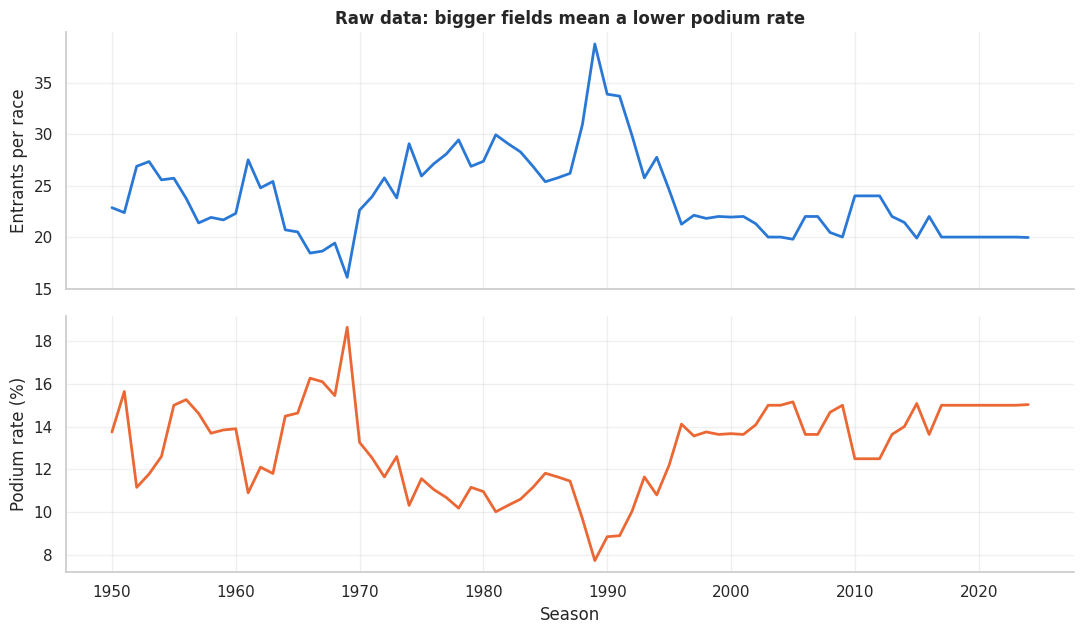

In [36]:
# --- Plot: entrants per race and podium rate (two panels, one scale each) -------------------------
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
axes[0].plot(context_raw.index, context_raw["entrants_per_race"], color=PALETTE[0])
axes[0].set_ylabel("Entrants per race")
axes[0].set_title("Raw data: bigger fields mean a lower podium rate")
axes[1].plot(context_raw.index, context_raw["podium_rate_%"], color=PALETTE[1])
axes[1].set_ylabel("Podium rate (%)")
axes[1].set_xlabel("Season")
plt.tight_layout()
plt.show()

**Finding:** podiums are a **minority class** in every season, and the rate moves inversely with field size
(lowest in the late 1980s, when many non-qualifiers have result rows).

**Decision:** class imbalance is handed over to modeling (supports PR-AUC as the primary metric and class weights).
Part of the low rate is caused by non-starter rows, which 2.6 removes; 3.6 shows the effect.

## 1.9 Do the values make sense together?
Sections 1.1–1.8 checked that values exist and have the right format. These checks test whether values are
**consistent with each other** (a race has exactly 3 podium places, a driver's age on race day is plausible, etc.).
The same function is re-run after cleaning in 3.7.

In [37]:
# --- Consistency checks ------------------------------------------------------------------
# Each check returns the number of violating rows. Works on raw (text) and clean (typed)
# tables, because every value is converted with to_num / to_datetime inside.
def consistency_checks(tables):
    f = lambda s: to_num(s).astype("float64")
    races = tables["races"].assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"))
    res = tables["results"].merge(races[["raceId", "date"]], on="raceId", how="left")
    dob = pd.to_datetime(res["driverId"].map(tables["drivers"].set_index("driverId")["dob"]), errors="coerce")
    age = (res["date"] - dob).dt.days / 365.25
    pos, order, grid = f(res["position"]), f(res["positionOrder"]), f(res["grid"])
    podiums = (order <= PODIUM_CUTOFF).groupby(res["raceId"]).sum()
    starters = res.groupby("raceId").size()
    qual = tables["qualifying"]
    res_keys = res.set_index(["raceId", "driverId"]).index
    rows = [
        ("races", "season year differs from year of race date",
         (races["year"] != races["date"].dt.year).sum()),
        ("races", "duplicate (year, round)",
         races.duplicated(["year", "round"]).sum()),
        ("results", "driver age on race day outside 17-60",
         ((age < 17) | (age > 60)).sum()),
        ("results", "negative points or laps",
         ((f(res["points"]) < 0) | (f(res["laps"]) < 0)).sum()),
        ("results", "classified position differs from positionOrder",
         (pos.notna() & (pos != order)).sum()),
        ("results", "rows sharing a positionOrder with another driver",
         res.assign(_o=order).duplicated(["raceId", "_o"], keep=False).sum()),
        ("results", "races without exactly 3 podium rows",
         (podiums[starters >= 3] != 3).sum()),
        ("results", "rows sharing a grid slot (> 0) with another driver",
         res.assign(_g=grid)[grid > 0].duplicated(["raceId", "_g"], keep=False).sum()),
        ("qualifying", "duplicate qualifying position within a race",
         qual.duplicated(["raceId", "position"]).sum()),
        ("qualifying", "qualifying rows without a results row",
         (~qual.set_index(["raceId", "driverId"]).index.isin(res_keys)).sum()),
    ]
    return pd.DataFrame([(t, c, int(v)) for t, c, v in rows], columns=["table", "check", "violations"])

consistency_raw = consistency_checks(raw)
consistency_raw

,table,check,violations
0,races,season year differs from year of race date,0
1,races,"duplicate (year, round)",0
2,results,driver age on race day outside 17-60,0
3,results,negative points or laps,0
4,results,classified position differs from positionOrder,13
5,results,rows sharing a positionOrder with another driver,228
6,results,races without exactly 3 podium rows,18
7,results,rows sharing a grid slot (> 0) with another dr...,377
8,qualifying,duplicate qualifying position within a race,0
9,qualifying,qualifying rows without a results row,0


In [38]:
# --- Detail: where classified position and positionOrder disagree -------------------------
r = res_raw.assign(pos=to_num(res_raw["position"]))
mismatch_races = r.loc[r["pos"].notna() & (r["pos"] != r["positionOrder"]), "raceId"].unique()
display(r[r["raceId"].isin(mismatch_races) & (r["positionOrder"] <= 5)]
        [["year", "name", "driverId", "position", "positionText", "positionOrder", "status"]])

,year,name,driverId,position,positionText,positionOrder,status
10655,1983,Brazilian Grand Prix,137,1,1,1,Finished
10656,1983,Brazilian Grand Prix,182,3,3,2,Finished
10657,1983,Brazilian Grand Prix,172,4,4,3,Finished
10658,1983,Brazilian Grand Prix,175,5,5,4,Finished
10659,1983,Brazilian Grand Prix,176,6,6,5,Finished


In [39]:
# --- Detail: drivers sharing a finishing position (positionOrder) ----------------------------
ties = res_raw[res_raw.duplicated(["raceId", "positionOrder"], keep=False)]
print("Seasons with tied positionOrder:", ties["year"].min(), "-", ties["year"].max())
display(ties.sort_values(["raceId", "positionOrder", "resultId"])
        [["year", "name", "driverId", "resultId", "number", "grid", "positionOrder", "points"]].head(8))

Seasons with tied positionOrder: 1950 - 1964


,year,name,driverId,resultId,number,grid,positionOrder,points
17367,1964,United States Grand Prix,374,17368,2,1,12,0.0
24298,1964,United States Grand Prix,373,24304,2,1,12,0.0
17961,1961,British Grand Prix,475,17962,26,20,19,0.0
20296,1961,British Grand Prix,486,20299,26,20,19,0.0
18056,1961,United States Grand Prix,482,18057,21,15,11,0.0
24297,1961,United States Grand Prix,418,24303,21,15,11,0.0
18068,1960,Argentine Grand Prix,427,18069,38,8,3,0.0
20295,1960,Argentine Grand Prix,475,22372,38,8,3,0.0


In [40]:
# --- Detail: shared grid slots per decade ----------------------------------------------------------
g = res_raw[res_raw["grid"] > 0]
shared_grid = g[g.duplicated(["raceId", "grid"], keep=False)]
(shared_grid["year"] // 10 * 10).value_counts().sort_index().rename("rows sharing a grid slot").to_frame()

,rows sharing a grid slot
year,
1950,244
1960,39
1970,46
1980,26
1990,14
2000,2
2010,4
2020,2


**Finding:**
- **Passed:** season years match race dates, rounds are unique, ages are plausible, no negative points/laps, qualifying positions are unique
  and every qualifying row has a results row (check the table above on your run).
- **`position` ≠ `positionOrder`** in a single race (shown above): a driver was disqualified and his place was officially left **vacant**.
  `position` keeps the official numbers, `positionOrder` closes the gap, so the driver who officially finished 4th has `positionOrder = 3`.
- **Tied `positionOrder` and races with ≠ 3 podium rows** occur only in the 1950s–60s: in a shared drive, *every* driver of a car is
  credited with that car's result, so one car is counted more than once.
- **Shared grid slots** appear in a small number of rows across many decades.

**Decision:**
- `positionOrder` stays the target, as the brief defines; the vacant-place race is documented as a known limitation.
- Ties are fixed by the grain step: 2.7 removes the duplicate rows, and **2.7b** removes **relief drivers** (drivers whose only entry is a car
  someone else started), using the same principle as 2.6: only drivers who took the start are predictions.
- Shared grid slots cannot be resolved from this dataset (no second source for the true grid); they are left as-is and documented.
- All checks are re-run after cleaning (3.7).

# 2. Data Cleaning & Auditing

Every step below is justified by a finding from Section 1. The order matters:

| Step | What | Why this position |
|---|---|---|
| 2.1 | Work on copies | Raw tables must stay immutable |
| 2.2 | `\N` → `NaN` | Everything after needs real missing values |
| 2.3 | Semantic typing (numbers, dates, clock times, durations) | Needs 2.2 first, otherwise `\N` breaks the parsing |
| 2.4 | Drop (almost) empty columns | Measured on the typed data |
| 2.5 | Primary/foreign key audit | IDs are numeric now, so comparisons are exact |
| 2.6 | Remove out-of-scope rows (non-starters, Indy 500) | Before de-duplication, because some duplicates are non-starter entries |
| 2.7 | One row per `(raceId, driverId)`, then relief drivers (2.7b) | Only real race starts are left to choose between |
| 2.8 | Final checks, cleaning log, handover | Proves the result and documents it |

**Team decisions:** out-of-scope rows are **removed during cleaning**; **all 14 tables** are cleaned.

## 2.1 Start from copies

In [41]:
# --- Copies of all 14 raw tables + an empty cleaning log ------------------------------------------
# `clean` is the dictionary handed to the rest of the team.
clean = {t: get_table(t) for t in TABLES}
cleaning_log = []

def log(step, table, affected, rule):
    # Records one cleaning action; summarised in 2.8.
    cleaning_log.append({"step": step, "table": table, "affected": int(affected), "rule": rule})

print({t: df.shape for t, df in clean.items()})

{'circuits': (77, 9), 'constructors': (212, 5), 'constructor_results': (12625, 5), 'constructor_standings': (13391, 7), 'drivers': (861, 9), 'driver_standings': (34863, 7), 'races': (1125, 18), 'results': (26759, 18), 'qualifying': (10494, 9), 'lap_times': (589081, 6), 'pit_stops': (11371, 7), 'sprint_results': (360, 16), 'seasons': (75, 2), 'status': (139, 2)}


## 2.2 Sentinels: `\N` → `NaN`
`\N` is replaced in **every** table, so that pandas recognises the value as missing.

In [42]:
# --- Replace the sentinel in every table ---------------------------------------------------------
for t, df in clean.items():
    n = int((df.astype(str) == SENTINEL).sum().sum())
    if n:
        clean[t] = df.replace(SENTINEL, np.nan)
        log("2.2 sentinel", t, n, r"'\N' -> NaN (cells)")

remaining = sum(int((df.astype(str) == SENTINEL).sum().sum()) for df in clean.values())
assert remaining == 0, "Sentinels still present"
print(r"No '\N' left in any table ✔")
pd.DataFrame(cleaning_log)

No '\N' left in any table ✔


,step,table,affected,rule
0,2.2 sentinel,constructor_results,12608,'\N' -> NaN (cells)
1,2.2 sentinel,drivers,1559,'\N' -> NaN (cells)
2,2.2 sentinel,races,11349,'\N' -> NaN (cells)
3,2.2 sentinel,results,122887,'\N' -> NaN (cells)
4,2.2 sentinel,qualifying,11600,'\N' -> NaN (cells)
5,2.2 sentinel,sprint_results,73,'\N' -> NaN (cells)


## 2.3 Semantic typing
Four conversions, following the plan from 1.4. Each one checks that **no non-missing value was lost** during parsing.

### 2.3a Numbers stored as text → numeric
A text column is converted **only if every non-missing value parses as a number**, so real text columns
(names, codes, `positionText` letters) are never touched. Whole numbers become the nullable integer type `Int64`,
which can hold missing values without turning into floats.

In [43]:
# --- Generic numeric conversion -------------------------------------------------------------------
def numeric_if_possible(s):
    conv = pd.to_numeric(s, errors="coerce")
    if conv[s.notna()].isna().any():
        return None                       # at least one real text value -> leave the column alone
    if (conv.dropna() % 1 == 0).all():
        return conv.astype("Int64")       # whole numbers -> nullable integer
    return conv.astype("float64")

converted = []
for t, df in clean.items():
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]) or df[c].isna().all():
            continue
        conv = numeric_if_possible(df[c])
        if conv is not None:
            df[c] = conv
            converted.append(f"{t}.{c}")
            log("2.3a numeric", t, conv.notna().sum(), f"{c}: text -> {conv.dtype}")
print(f"{len(converted)} columns converted:\n" + ", ".join(converted))

10 columns converted:
drivers.number, results.number, results.position, results.milliseconds, results.fastestLap, results.rank, results.fastestLapSpeed, sprint_results.position, sprint_results.milliseconds, sprint_results.fastestLap


### 2.3b Dates → `datetime64`

In [44]:
# --- Date columns ------------------------------------------------------------------------------------
# Strict format: any value that does not match YYYY-MM-DD would fail the check below.
DATE_COLUMNS = {
    "races":   ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"],
    "drivers": ["dob"],
}
for t, cols in DATE_COLUMNS.items():
    for c in cols:
        if c not in clean[t]:
            continue
        before = clean[t][c].notna().sum()
        clean[t][c] = pd.to_datetime(clean[t][c], format="%Y-%m-%d", errors="coerce")
        lost = before - clean[t][c].notna().sum()
        assert lost == 0, f"{t}.{c}: {lost} values failed to parse"
        log("2.3b date", t, before, f"{c}: text -> datetime64")
clean["races"][["date", "quali_date"]].dtypes

date          datetime64[ns]
quali_date    datetime64[ns]
dtype: object

### 2.3c Clock times → `timedelta`
These are times of day (e.g. race start `06:00:00`, stored in UTC), not durations. They become a `timedelta`
(time since midnight), which can be added to the matching date column when a full timestamp is needed.

In [45]:
# --- Clock-time columns ----------------------------------------------------------------------------
CLOCK_COLUMNS = {
    "races":     ["time", "fp1_time", "fp2_time", "fp3_time", "quali_time", "sprint_time"],
    "pit_stops": ["time"],
}
for t, cols in CLOCK_COLUMNS.items():
    for c in cols:
        if c not in clean[t]:
            continue
        before = clean[t][c].notna().sum()
        clean[t][c] = pd.to_timedelta(clean[t][c], errors="coerce")
        lost = before - clean[t][c].notna().sum()
        assert lost == 0, f"{t}.{c}: {lost} values failed to parse"
        log("2.3c clock time", t, before, f"{c}: text -> timedelta (time of day)")
clean["races"][["date", "time"]].head(3)

,date,time
0,2009-03-29,0 days 06:00:00
1,2009-04-05,0 days 09:00:00
2,2009-04-19,0 days 07:00:00


### 2.3d Durations → seconds
One parser handles every format found in 1.4 by reading the parts from left to right
(`h:mm:ss.sss`, `m:ss.sss`, `m:ss`, `ss.sss`). The result goes into a new column named `<column>_sec`
so the unit is explicit, and the original text column is dropped.

In [46]:
# --- Duration parser ---------------------------------------------------------------------------------
def duration_to_seconds(value):
    # "1:27.452" -> 87.452 | "49.111" -> 49.111 | "1:38" -> 98.0 | "1:02:03.5" -> 3723.5
    if pd.isna(value):
        return np.nan
    seconds = 0.0
    try:
        for part in str(value).split(":"):
            seconds = seconds * 60 + float(part)
    except ValueError:
        return np.nan
    return seconds

for example in ["1:27.452", "49.111", "1:38", "1:02:03.5"]:
    print(f"{example:>10} -> {duration_to_seconds(example)}")

  1:27.452 -> 87.452
    49.111 -> 49.111
      1:38 -> 98.0
 1:02:03.5 -> 3723.5


In [47]:
# --- Apply the parser ----------------------------------------------------------------------------------
DURATION_COLUMNS = {
    "qualifying":     ["q1", "q2", "q3"],
    "results":        ["fastestLapTime"],
    "sprint_results": ["fastestLapTime"],
    "lap_times":      ["time"],
    "pit_stops":      ["duration"],
}
for t, cols in DURATION_COLUMNS.items():
    for c in cols:
        if c not in clean[t]:
            continue
        before = clean[t][c].notna().sum()
        new_col = f"{c}_sec"
        clean[t][new_col] = clean[t][c].map(duration_to_seconds).astype("float64")
        lost = before - clean[t][new_col].notna().sum()
        assert lost == 0, f"{t}.{c}: {lost} values failed to parse"
        clean[t] = clean[t].drop(columns=c)
        log("2.3d duration", t, before, f"{c}: text -> {new_col} (seconds)")
clean["qualifying"].head(3)

,qualifyId,raceId,driverId,constructorId,number,position,q1_sec,q2_sec,q3_sec
0,1,18,1,1,22,1,86.572,85.187,86.714
1,2,18,9,2,4,2,86.103,85.315,86.869
2,3,18,5,1,23,3,85.664,85.452,87.079


In [48]:
# --- Validate the parser against the dataset's own millisecond columns ------------------------------
# lap_times and pit_stops store each time twice (text + milliseconds). If the parser is
# right, parsed seconds == milliseconds / 1000.
for t, col in [("lap_times", "time_sec"), ("pit_stops", "duration_sec")]:
    df = clean[t].dropna(subset=[col, "milliseconds"])
    diff = (df[col] - df["milliseconds"] / 1000).abs()
    print(f"{t:<10} rows compared: {len(df):>7,} | exact (< 1 ms): {(diff < 0.001).mean():.4%} "
          f"| rows off by >= 1 ms: {(diff >= 0.001).sum()} | max difference: {diff.max():.3f} s")

lap_times  rows compared: 589,081 | exact (< 1 ms): 100.0000% | rows off by >= 1 ms: 0 | max difference: 0.000 s
pit_stops  rows compared:  11,371 | exact (< 1 ms): 100.0000% | rows off by >= 1 ms: 0 | max difference: 0.000 s


**Result:** parsed seconds match `milliseconds / 1000` for (almost) every row, which proves the parser handles all formats.
Any remaining small differences come from text values stored **without** decimals (shape `9:99`) in the source data, i.e. the text
was rounded to whole seconds while `milliseconds` kept the exact value. This is a precision limit of the source, not a parsing error.

**Not converted, on purpose:** `results.time` and `sprint_results.time` mix total race time with gaps to the winner (1.4).
They stay as text; their numeric equivalent is `milliseconds`. Both are post-race and never used as features.

## 2.4 Drop (almost) empty columns
**Rule:** drop a column if **≥ 99 %** of its values are missing.
The threshold is deliberately high: `races.sprint_date` / `sprint_time` are ~98 % missing but are *structurally* missing
(only sprint weekends have a sprint), so they carry real information and must be kept.

In [49]:
# --- Find and drop near-empty columns -------------------------------------------------------------------
EMPTY_THRESHOLD = 99.0
profile = missing_profile(clean)
to_drop = profile[profile["missing_%"] >= EMPTY_THRESHOLD]
display(to_drop.round(2))

for _, r in to_drop.iterrows():
    clean[r["table"]] = clean[r["table"]].drop(columns=r["column"])
    log("2.4 drop column", r["table"], r["rows"], f"{r['column']}: {r['missing_%']:.2f}% missing")

,table,column,rows,missing,missing_%
18,constructor_results,status,12625,12608,99.87


## 2.5 Primary and foreign keys
Same audit functions as 1.6, now on typed data. Any problem found is fixed and logged.

In [50]:
# --- Primary keys after typing ---------------------------------------------------------------------------
pk_audit(clean)

,table,primary_key,duplicates,nulls
0,circuits,circuitId,0,0
1,constructors,constructorId,0,0
2,constructor_results,constructorResultsId,0,0
3,constructor_standings,constructorStandingsId,0,0
4,drivers,driverId,0,0
5,driver_standings,driverStandingsId,0,0
6,races,raceId,0,0
7,results,resultId,0,0
8,qualifying,qualifyId,0,0
9,lap_times,"raceId, driverId, lap",0,0


In [51]:
# --- Fix duplicate primary keys (if any) ---------------------------------------------------------------
# Rows with a repeated primary key are dropped, keeping the first. The output says how many
# of them were exact copies. Note: results is unique on resultId; its (raceId, driverId)
# grain problem is a different issue, handled in 2.7.
for t, k in PRIMARY_KEYS.items():
    n_dup = int(clean[t].duplicated(k).sum())
    if n_dup:
        n_exact = int(clean[t].duplicated().sum())
        clean[t] = clean[t].drop_duplicates(subset=k, keep="first").reset_index(drop=True)
        log("2.5 primary key", t, n_dup, f"duplicate {k} dropped ({n_exact} exact copies)")
        print(f"{t}: dropped {n_dup} duplicate-key rows ({n_exact} exact copies)")
assert pk_audit(clean)[["duplicates", "nulls"]].sum().sum() == 0
print("All primary keys unique and non-null ✔")

All primary keys unique and non-null ✔


In [52]:
# --- Foreign keys after typing: report and remove orphans --------------------------------------------------
fk_clean = fk_audit(clean)
for child, ccol, parent, pcol in FOREIGN_KEYS:
    df = clean[child]
    orphan = df[ccol].notna() & ~df[ccol].isin(clean[parent][pcol])
    if orphan.any():
        clean[child] = df[~orphan].reset_index(drop=True)
        log("2.5 foreign key", child, orphan.sum(), f"{ccol} not found in {parent}.{pcol}")
assert fk_audit(clean)["orphans"].sum() == 0
print(f"Orphans found: {fk_clean['orphans'].sum()} -> after fixing: 0 ✔")

Orphans found: 0 -> after fixing: 0 ✔


## 2.6 Remove out-of-scope rows
Based on 1.7. Each row of `results` is a prediction "will this driver finish on the podium in this race?",
which only makes sense for a driver who **took the start**:

| Removed | Rule | Why |
|---|---|---|
| Failed to qualify | `positionText == "F"` | Never started: no grid slot, nothing to predict |
| Withdrawn before the start | `positionText == "W"` and `laps == 0` | Never started |
| Indianapolis 500 (1950–1960) | race name `"Indianapolis 500"` | Separate event with its own drivers; distorts home-race and form statistics |

**Kept:** `grid = 0` with `laps > 0` (pit-lane starts). The Indy 500 is also removed from `qualifying` and `sprint_results`
(if present) so the race-entry tables stay consistent. `races` keeps it as a calendar record, and the standings tables are
official cumulative tables, so they are not changed.

In [53]:
# --- Flag the out-of-scope rows ------------------------------------------------------------------------------
res = clean["results"]
indy_race_ids = clean["races"].loc[clean["races"]["name"].eq("Indianapolis 500"), "raceId"]

is_dnq       = res["positionText"].eq("F")
is_withdrawn = res["positionText"].eq("W") & res["laps"].fillna(0).eq(0)
is_indy      = res["raceId"].isin(indy_race_ids)

scope_counts = pd.Series({
    "failed to qualify (F)":    int(is_dnq.sum()),
    "withdrawn, 0 laps (W)":    int(is_withdrawn.sum()),
    "Indianapolis 500":         int(is_indy.sum()),
    "total removed (any rule)": int((is_dnq | is_withdrawn | is_indy).sum()),
}, name="rows")
scope_counts.to_frame()

,rows
failed to qualify (F),1368
"withdrawn, 0 laps (W)",331
Indianapolis 500,405
total removed (any rule),2104


In [54]:
# --- Remove them ----------------------------------------------------------------------------------------------
rows_before_scope = len(res)
clean["results"] = res[~(is_dnq | is_withdrawn | is_indy)].reset_index(drop=True)
log("2.6 scope", "results", is_dnq.sum(), "removed: failed to qualify (positionText F)")
log("2.6 scope", "results", (is_withdrawn & ~is_dnq).sum(), "removed: withdrawn with 0 laps (positionText W)")
log("2.6 scope", "results", (is_indy & ~is_dnq & ~is_withdrawn).sum(), "removed: Indianapolis 500")

for t in ["qualifying", "sprint_results"]:
    indy_rows = clean[t]["raceId"].isin(indy_race_ids)
    if indy_rows.any():
        clean[t] = clean[t][~indy_rows].reset_index(drop=True)
        log("2.6 scope", t, indy_rows.sum(), "removed: Indianapolis 500")

print(f"results: {rows_before_scope:,} -> {len(clean['results']):,} rows")

results: 26,759 -> 24,655 rows


## 2.7 One row per `(raceId, driverId)`
After 2.6, every remaining duplicate is a **real shared drive**: the driver started in one car and later drove a
teammate's car. We need one rule that picks exactly one row per pair. Three candidate rules are tested below.

In [55]:
# --- Remaining duplicate pairs ---------------------------------------------------------------------------------
res = clean["results"]
pair_keys = ["raceId", "driverId"]
pairs = res[res.duplicated(pair_keys, keep=False)].copy()
n_pairs = pairs.groupby(pair_keys).ngroups
print(f"Rows involved: {len(pairs)} | pairs to resolve: {n_pairs}")

Rows involved: 125 | pairs to resolve: 61


In [56]:
# --- Candidate 1: "keep the row with a non-zero grid" ----------------------------------------------------------
# Works only if exactly one row of a pair has grid > 0.
resolved_by_grid = pairs.groupby(pair_keys)["grid"].apply(lambda g: (g > 0).sum() == 1)
print(f"Pairs this rule can resolve: {int(resolved_by_grid.sum())} of {n_pairs}")
print(f"Pairs where every row has grid > 0: {int(pairs.groupby(pair_keys)['grid'].apply(lambda g: (g > 0).all()).sum())}")

Pairs this rule can resolve: 0 of 61
Pairs where every row has grid > 0: 61


**Candidate 1 fails:** in shared drives, *both* rows carry a grid value (each car's starting slot), so "non-zero grid"
cannot tell them apart. We need a different signal for "the car he started in".

In [57]:
# --- Candidates 2 and 3: "best finishing position" vs "earliest entry" --------------------------------------------
best_finish   = pairs.sort_values(["positionOrder", "resultId"]).groupby(pair_keys).head(1)
earliest_entry = pairs.sort_values("resultId").groupby(pair_keys).head(1)

rule_compare = pd.DataFrame({
    "podium rows kept": [int((best_finish["positionOrder"] <= PODIUM_CUTOFF).sum()),
                         int((earliest_entry["positionOrder"] <= PODIUM_CUTOFF).sum())],
    "rows kept":        [len(best_finish), len(earliest_entry)],
}, index=["best positionOrder", "earliest entry (lowest resultId)"])
podium_best     = best_finish.set_index(pair_keys)["positionOrder"].sort_index() <= PODIUM_CUTOFF
podium_earliest = earliest_entry.set_index(pair_keys)["positionOrder"].sort_index() <= PODIUM_CUTOFF
changed = podium_best != podium_earliest
print(f"Pairs whose podium label depends on the rule: {int(changed.sum())} of {n_pairs}")
rule_compare

Pairs whose podium label depends on the rule: 15 of 61


,podium rows kept,rows kept
best positionOrder,21,61
earliest entry (lowest resultId),6,61


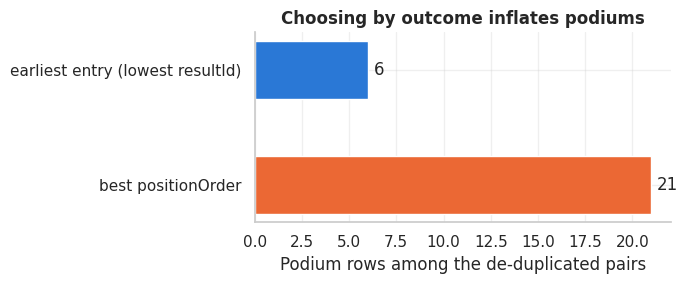

In [58]:
# --- Plot: podium rows kept by each rule ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(rule_compare.index, rule_compare["podium rows kept"], color=[PALETTE[1], PALETTE[0]], height=0.5)
for i, v in enumerate(rule_compare["podium rows kept"]):
    ax.text(v + 0.3, i, str(v), va="center")
ax.set_xlabel("Podium rows among the de-duplicated pairs")
ax.set_title("Choosing by outcome inflates podiums")
plt.tight_layout()
plt.show()

**Candidate 2 (best `positionOrder`) is rejected:** it chooses the row *by its result*, so the target decides which row survives.
That is **selection on the target**: it systematically keeps the better outcome and inflates podiums (plot above). It can also
pair a driver with the grid slot of a car he did not start in, which corrupts the `grid` feature.

**Candidate 3 (earliest entry, lowest `resultId`)** does not look at the outcome at all. The check below shows *why*
the lowest `resultId` is the car the driver started in.

In [59]:
# --- Evidence: the second row was appended later, out of sequence -------------------------------------------------
# For each race, take the resultId range of normal (non-duplicated) rows. The original entries
# sit inside that range; shared-drive rows added later have much higher ids.
normal_range = (res[~res.duplicated(pair_keys, keep=False)]
                .groupby("raceId")["resultId"].agg(["min", "max"]))
ev = pairs.join(normal_range, on="raceId")
ev["entry_order"] = ev.groupby(pair_keys)["resultId"].rank().astype(int).map({1: "1st entry", 2: "2nd entry", 3: "3rd entry"})
ev["inside_race_id_range"] = ev["resultId"].between(ev["min"], ev["max"])
pd.crosstab(ev["entry_order"], ev["inside_race_id_range"], margins=True)

inside_race_id_range,False,True,All
entry_order,,,
1st entry,7,54,61
2nd entry,43,18,61
3rd entry,2,1,3
All,52,73,125


In [60]:
# --- A known example: 1957 British Grand Prix ---------------------------------------------------------------------
# Historically, Stirling Moss started from pole in car #18, retired, took over Tony Brooks's
# car #20 and won. Brooks started car #20 from 3rd. The earliest-entry rule should keep
# Moss -> car 18 / grid 1, and Brooks -> car 20 / grid 3.
race_1957 = clean["races"].query("year == 1957 and name == 'British Grand Prix'")["raceId"]
drivers_ = clean["drivers"].set_index("driverId")["driverRef"]
example = pairs[pairs["raceId"].isin(race_1957)].assign(driver=lambda d: d["driverId"].map(drivers_))
example = example.sort_values(["driver", "resultId"])
example["kept_by_earliest_entry"] = ~example.duplicated(pair_keys)
example[["driver", "resultId", "number", "grid", "positionOrder", "points", "laps", "kept_by_earliest_entry"]]

,driver,resultId,number,grid,positionOrder,points,laps,kept_by_earliest_entry
17067,brooks,18806,20,3,1,4.0,90,True
18230,brooks,20293,18,1,12,0.0,51,False
17077,collins,18816,12,8,11,0.0,53,True
18229,collins,20292,16,9,4,0.0,88,False
17078,moss,18817,18,1,12,0.0,51,True
18228,moss,20291,20,3,1,5.0,90,False


**Chosen rule: keep the earliest entry (lowest `resultId`) for each `(raceId, driverId)`.**

Why:
1. **It represents the car the driver started in**, which is exactly what a pre-race prediction is about: its `grid` is the
   driver's real starting position. Most first entries sit inside the race's normal id range while later rows were appended
   out of sequence (crosstab above), and the 1957 British GP shows the rule reproduces the known history.
2. **It never looks at the outcome**, so the label is not used to choose the row (unlike "best finish").
3. **It always resolves a pair** (ids are unique), unlike "non-zero grid".

**Trade-off:** the driver's result in the *second* car (e.g. Moss's 1957 win in Brooks's car) is not counted as his podium.
This affects only the pairs printed above (all before 1965), which is a small, documented effect.

In [61]:
# --- Apply the rule and prove the grain ---------------------------------------------------------------------------
rows_before_dedup = len(res)
clean["results"] = (res.sort_values("resultId")
                       .drop_duplicates(pair_keys, keep="first")
                       .reset_index(drop=True))
log("2.7 grain", "results", rows_before_dedup - len(clean["results"]),
    "shared drives: kept earliest entry (lowest resultId) per (raceId, driverId)")

assert not clean["results"].duplicated(pair_keys).any()
print(f"results: {rows_before_dedup:,} -> {len(clean['results']):,} rows | (raceId, driverId) is unique ✔")

results: 24,655 -> 24,591 rows | (raceId, driverId) is unique ✔


### 2.7b Relief drivers
In the 1950s a driver could take over a car mid-race **without having started the race in any car** (a "relief" driver).
His only row is the car another driver started, so after 2.7 that car's result appears twice: once for the driver who
started it and once for the relief driver (found in 1.9 as tied `positionOrder`).

**Rule:** within a race, if two drivers share a `positionOrder`, keep the earliest entry (the driver who started the car) and
remove the later one. **Why:** the relief driver never took the start, so there was no pre-race prediction to make for him, which is
the same reasoning as removing non-starters in 2.6. It also guarantees exactly three podium rows per race.

In [62]:
# --- Find and remove relief-driver rows ------------------------------------------------------------
res = clean["results"]
tied = res[res.duplicated(["raceId", "positionOrder"], keep=False)].sort_values(["raceId", "positionOrder", "resultId"])
relief_ids = tied.loc[tied.duplicated(["raceId", "positionOrder"]), "resultId"]   # later entry of each tie
display(tied[["raceId", "driverId", "resultId", "number", "grid", "positionOrder", "points"]].head(8))

clean["results"] = res[~res["resultId"].isin(relief_ids)].reset_index(drop=True)
log("2.7 grain", "results", len(relief_ids),
    "relief drivers: removed later entry sharing a car's positionOrder with the driver who started it")

res = clean["results"]
podiums = (res["positionOrder"] <= PODIUM_CUTOFF).groupby(res["raceId"]).sum()
assert not res.duplicated(["raceId", "positionOrder"]).any()
assert (podiums[res.groupby("raceId").size() >= 3] == 3).all()
print(f"Removed {len(relief_ids)} relief-driver rows | every race now has exactly 3 podium rows ✔")

,raceId,driverId,resultId,number,grid,positionOrder,points
16428,742,475,17962,26,20,19,0.0
18174,742,486,20299,26,20,19,0.0
17025,776,606,18727,20,10,5,1.0
18171,776,498,20285,20,10,5,1.0
17026,776,607,18728,18,11,6,0.0
18172,776,476,20287,18,11,6,0.0
17134,783,609,18875,28,16,11,0.0
18173,783,638,20295,28,16,11,0.0


Removed 21 relief-driver rows | every race now has exactly 3 podium rows ✔


## 2.8 Final checks, cleaning log and handover

In [63]:
# --- Final checks ---------------------------------------------------------------------------------------------------
# 1) grain of every table joined on (raceId, driverId / constructorId)
for t, k in grain_keys.items():
    assert not clean[t].duplicated(k).any(), f"{t} not unique on {k}"
assert not clean["results"].duplicated(["raceId", "positionOrder"]).any()
# 2) keys
assert pk_audit(clean)[["duplicates", "nulls"]].sum().sum() == 0
assert fk_audit(clean)["orphans"].sum() == 0
# 3) no sentinel anywhere
assert sum(int((df.astype(str) == SENTINEL).sum().sum()) for df in clean.values()) == 0
# 4) the raw tables were never modified
assert_raw_unchanged()
print("All final checks passed ✔")

Raw tables unchanged ✔
All final checks passed ✔


In [64]:
# --- Cleaning log ------------------------------------------------------------------------------------------------------
cleaning_log_df = pd.DataFrame(cleaning_log)
print(f"{len(cleaning_log_df)} logged actions")
cleaning_log_df.groupby("step").agg(actions=("rule", "size"), affected=("affected", "sum"))

43 logged actions


,actions,affected
step,,
2.2 sentinel,6,160076
2.3a numeric,10,76348
2.3b date,7,2346
2.3c clock time,7,12037
2.3d duration,7,628869
2.4 drop column,1,12625
2.6 scope,3,2104
2.7 grain,2,85


In [65]:
# --- Full log (every individual action) -----------------------------------------------------------------------------------
pd.set_option("display.max_rows", 200)
display(cleaning_log_df)
pd.reset_option("display.max_rows")

,step,table,affected,rule
0,2.2 sentinel,constructor_results,12608,'\N' -> NaN (cells)
1,2.2 sentinel,drivers,1559,'\N' -> NaN (cells)
2,2.2 sentinel,races,11349,'\N' -> NaN (cells)
3,2.2 sentinel,results,122887,'\N' -> NaN (cells)
4,2.2 sentinel,qualifying,11600,'\N' -> NaN (cells)
5,2.2 sentinel,sprint_results,73,'\N' -> NaN (cells)
6,2.3a numeric,drivers,59,number: text -> Int64
7,2.3a numeric,results,26753,number: text -> Int64
8,2.3a numeric,results,15806,position: text -> Int64
9,2.3a numeric,results,7680,milliseconds: text -> Int64


### Handover to the team
`clean` is a dictionary of the 14 cleaned tables (same names as `raw`). What changed compared to the raw CSVs:

- **Missing values** are `NaN` / `NaT` / `<NA>` everywhere (no `\N`). Nothing was imputed; the meaning of missingness per column is:
  - `qualifying.q2_sec`, `q3_sec`: driver did not reach that session (or pre-2006 format) → *slower*, not unknown.
  - `races.*_date`, `races.*_time`, `fastestLapTime_sec`: not recorded in older seasons.
  - `results.position`, `milliseconds`: driver not classified / did not finish (post-race, never a feature).
- **Renamed columns** (durations in seconds): `qualifying.q1/q2/q3` → `q1_sec/q2_sec/q3_sec`, `results.fastestLapTime` and
  `sprint_results.fastestLapTime` → `fastestLapTime_sec`, `lap_times.time` → `time_sec`, `pit_stops.duration` → `duration_sec`.
- **Dates** are `datetime64`; **clock times** (`races.*time`, `pit_stops.time`) are `timedelta` since midnight.
- **Dropped columns:** see 2.4 (e.g. `constructor_results.status`).
- **results** contains only drivers who **took the start** (no non-starters, no relief drivers), excludes the **Indianapolis 500**,
  is **unique on `(raceId, driverId)`**, and every race has exactly 3 podium rows.
- Known source limitations (1.9): one race where a disqualified driver's place was left vacant (`position` ≠ `positionOrder`),
  and a few rows sharing a grid slot.
- `qualifying` still contains drivers who failed to qualify; they drop out automatically when joining from `results`.
- **Not changed:** standings tables (still *after* each race, must be shifted before use as features), `results.time` (text).
- Qualifying data only exists from the mid-1990s and has a coverage gap around the late 1990s / early 2000s (1.3).
- A few extreme qualifying times exist (3.5): consider capping them or using a relative gap-to-pole feature.

# 3. Post-cleaning EDA
The same measurements as Section 1, re-run on `clean`, to show the **impact** of each cleaning step.

## 3.1 Missing values: before vs after

In [66]:
# --- Missing values in core columns, raw vs clean -------------------------------------------------------------------
# Renamed duration columns are mapped back to their raw names so they can be compared.
renamed = {(t, f"{c}_sec"): c for t, cols in DURATION_COLUMNS.items() for c in cols}
clean_missing = missing_profile(clean)
clean_missing["column"] = [renamed.get((t, c), c) for t, c in zip(clean_missing["table"], clean_missing["column"])]

before_after = (raw_missing.merge(clean_missing, on=["table", "column"], how="left", suffixes=("_raw", "_clean"))
                [["table", "column", "rows_raw", "missing_raw", "missing_%_raw",
                  "rows_clean", "missing_clean", "missing_%_clean"]])
before_after = before_after[before_after["missing_raw"] > 0].reset_index(drop=True)
display(before_after.round(2))

,table,column,rows_raw,missing_raw,missing_%_raw,rows_clean,missing_clean,missing_%_clean
0,constructor_results,status,12625,12608,99.87,NaN,NaN,NaN
1,drivers,number,861,802,93.15,861.0,802.0,93.15
2,drivers,code,861,757,87.92,861.0,757.0,87.92
3,races,time,1125,731,64.98,1125.0,731.0,64.98
4,races,fp1_date,1125,1035,92.00,1125.0,1035.0,92.00
5,races,fp1_time,1125,1057,93.96,1125.0,1057.0,93.96
6,races,fp2_date,1125,1035,92.00,1125.0,1035.0,92.00
7,races,fp2_time,1125,1057,93.96,1125.0,1057.0,93.96
8,races,fp3_date,1125,1053,93.60,1125.0,1053.0,93.60
9,races,fp3_time,1125,1072,95.29,1125.0,1072.0,95.29


In [67]:
# --- Consistency check: sentinel handling neither created nor lost missing values -------------------------------------
# For tables whose row count did not change, missing cells after cleaning must equal
# missing cells (\N + empty) before cleaning, column by column. Dropped columns are skipped.
same_rows = before_after["rows_raw"] == before_after["rows_clean"]
check = before_after[same_rows & before_after["rows_clean"].notna()]
mismatch = check[check["missing_raw"] != check["missing_clean"]]
print(f"Columns compared: {len(check)} | mismatches: {len(mismatch)}")
display(mismatch)

Columns compared: 21 | mismatches: 0


,table,column,rows_raw,missing_raw,missing_%_raw,rows_clean,missing_clean,missing_%_clean


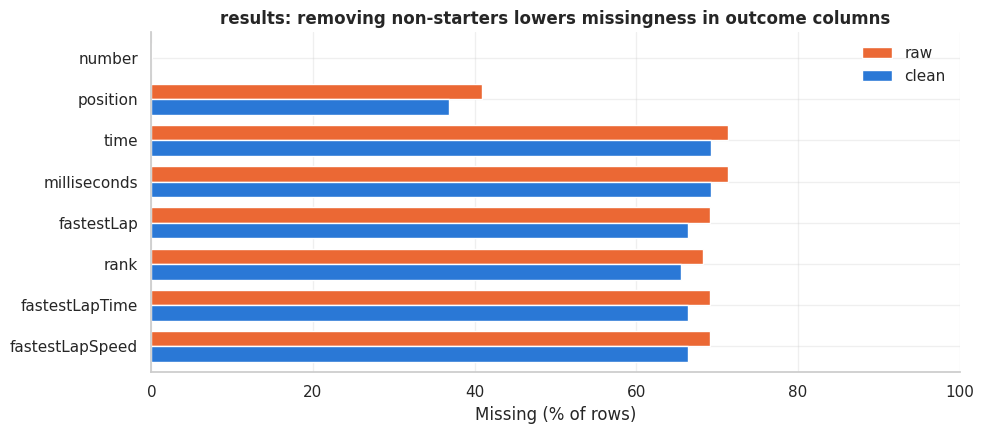

In [68]:
# --- Plot: results columns, missing % before vs after -----------------------------------------------------------------
# results lost rows in 2.6/2.7, so its percentages change; the plot shows by how much.
r = before_after[before_after["table"] == "results"].set_index("column")[["missing_%_raw", "missing_%_clean"]]
r.columns = ["raw", "clean"]

fig, ax = plt.subplots(figsize=(10, 4.5))
r.plot(kind="barh", ax=ax, color=[PALETTE[1], PALETTE[0]], width=0.75, edgecolor="white")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Missing (% of rows)")
ax.set_ylabel("")
ax.set_title("results: removing non-starters lowers missingness in outcome columns")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Impact:** sentinel handling is lossless (mismatch table empty: every `\N`/empty cell became exactly one missing value, and
no valid value was lost in typing). In `results`, the share of missing `position` / `time` values drops because most of those
rows were non-starters, which 2.6 removed.

## 3.2 Types: before vs after

In [69]:
# --- Columns whose dtype changed --------------------------------------------------------------------------------------
rows = []
for t in TABLES:
    for c in raw[t].columns:
        new_c = f"{c}_sec" if f"{c}_sec" in clean[t] else c
        if new_c not in clean[t]:
            rows.append({"table": t, "column": c, "raw dtype": str(raw[t][c].dtype), "clean": "dropped", "clean dtype": "-"})
        elif str(raw[t][c].dtype) != str(clean[t][new_c].dtype):
            rows.append({"table": t, "column": c, "raw dtype": str(raw[t][c].dtype),
                         "clean": new_c, "clean dtype": str(clean[t][new_c].dtype)})
dtype_changes = pd.DataFrame(rows)
print(f"{len(dtype_changes)} columns changed type or were dropped")
dtype_changes

32 columns changed type or were dropped


,table,column,raw dtype,clean,clean dtype
0,constructor_results,status,object,dropped,-
1,drivers,number,object,number,Int64
2,drivers,dob,object,dob,datetime64[ns]
3,races,date,object,date,datetime64[ns]
4,races,time,object,time,timedelta64[ns]
5,races,fp1_date,object,fp1_date,datetime64[ns]
6,races,fp1_time,object,fp1_time,timedelta64[ns]
7,races,fp2_date,object,fp2_date,datetime64[ns]
8,races,fp2_time,object,fp2_time,timedelta64[ns]
9,races,fp3_date,object,fp3_date,datetime64[ns]


## 3.3 Grain: before vs after

In [70]:
# --- Duplicate keys before vs after ------------------------------------------------------------------------------------
grain_compare = pd.DataFrame({
    "raw":   grain_raw,
    "clean": pd.Series({t: int(clean[t].duplicated(k).sum()) for t, k in grain_keys.items()}),
})
grain_compare

,raw,clean
results,91,0
qualifying,0,0
sprint_results,0,0
driver_standings,0,0
constructor_standings,0,0
constructor_results,0,0


## 3.4 What cleaning removed from `results`

In [71]:
# --- Row funnel for results ---------------------------------------------------------------------------------------------
removed = cleaning_log_df[cleaning_log_df["table"].eq("results") & cleaning_log_df["step"].str.startswith(("2.5", "2.6", "2.7"))]
funnel = [("raw", len(raw["results"]))]
n = len(raw["results"])
for _, row in removed.iterrows():
    n -= row["affected"]
    funnel.append((row["rule"].replace("removed: ", "").split(":")[0], n))
funnel = pd.DataFrame(funnel, columns=["after step", "rows"])
assert funnel["rows"].iloc[-1] == len(clean["results"])
funnel

,after step,rows
0,raw,26759
1,failed to qualify (positionText F),25391
2,withdrawn with 0 laps (positionText W),25060
3,Indianapolis 500,24655
4,shared drives,24591
5,relief drivers,24570


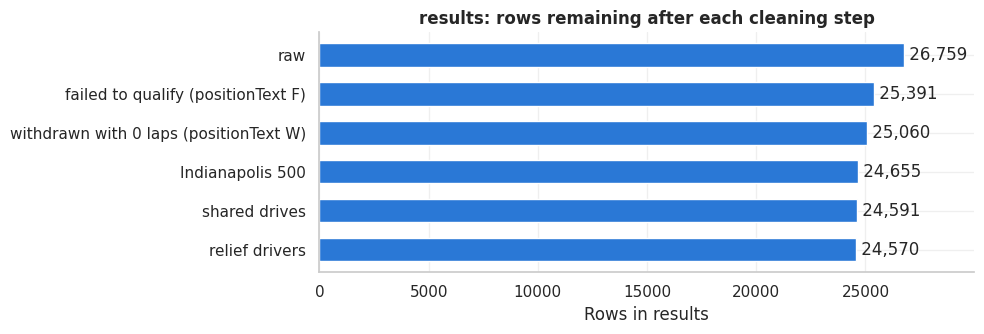

In [72]:
# --- Plot: results row funnel --------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(funnel["after step"], funnel["rows"], color=PALETTE[0], height=0.6)
ax.invert_yaxis()
for i, v in enumerate(funnel["rows"]):
    ax.text(v, i, f" {v:,}", va="center")
ax.set_xlim(0, funnel["rows"].max() * 1.12)
ax.set_xlabel("Rows in results")
ax.set_title("results: rows remaining after each cleaning step")
plt.tight_layout()
plt.show()

## 3.5 Do the newly typed values make sense?

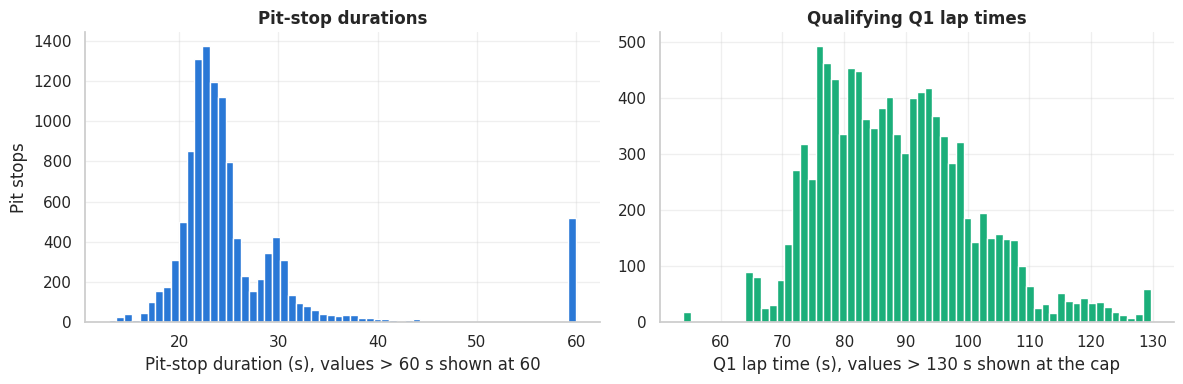

Pit stops > 60 s: 517 of 11,371 | median 23.6 s
Q1 times: min 53.9 s, median 87.1 s, max 1002.6 s | above 130 s: 52


In [73]:
# --- Distribution of parsed durations -----------------------------------------------------------------------------------------
# Pit stops: the bulk is a normal stop; very long values are stops during red flags or repairs.
# Qualifying q1: lap times depend on the circuit, so a wide spread is expected.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ps = clean["pit_stops"]["duration_sec"].dropna()
axes[0].hist(ps.clip(upper=60), bins=60, color=PALETTE[0])
axes[0].set_xlabel("Pit-stop duration (s), values > 60 s shown at 60")
axes[0].set_ylabel("Pit stops")
axes[0].set_title("Pit-stop durations")
q1 = clean["qualifying"]["q1_sec"].dropna()
q1_cap = q1.quantile(0.995)
axes[1].hist(q1.clip(upper=q1_cap), bins=60, color=PALETTE[2])
axes[1].set_xlabel(f"Q1 lap time (s), values > {q1_cap:.0f} s shown at the cap")
axes[1].set_title("Qualifying Q1 lap times")
plt.tight_layout()
plt.show()

print(f"Pit stops > 60 s: {(ps > 60).sum()} of {len(ps):,} | median {ps.median():.1f} s")
print(f"Q1 times: min {q1.min():.1f} s, median {q1.median():.1f} s, max {q1.max():.1f} s "
      f"| above {q1_cap:.0f} s: {(q1 > q1_cap).sum()}")

**Impact:** after parsing, durations are real numbers and the bulk of each distribution is in a plausible range
(pit stops around 20–30 s, Q1 laps between roughly 1 and 2 minutes depending on the circuit).

**Outliers are kept in cleaning, on purpose:** very long pit stops are mostly red-flag interruptions or repairs (real events),
and pit stops are post-race data that never become features. The few extreme Q1 values (see the printout) are recorded that
way in the source; whether to cap them is a **feature decision**: a relative measure such as "gap to pole in %" makes them
easy to spot and handle. This is noted in the handover.

## 3.6 Field size and target balance: before vs after

In [74]:
# --- Recompute the season context on clean data -----------------------------------------------------------------------------
context_clean = season_context(clean["results"], clean["races"])
print(f"Overall podium rate: raw {(to_num(raw['results']['positionOrder']) <= PODIUM_CUTOFF).mean():.1%} "
      f"-> clean {(clean['results']['positionOrder'] <= PODIUM_CUTOFF).mean():.1%}")

Overall podium rate: raw 12.7% -> clean 13.6%


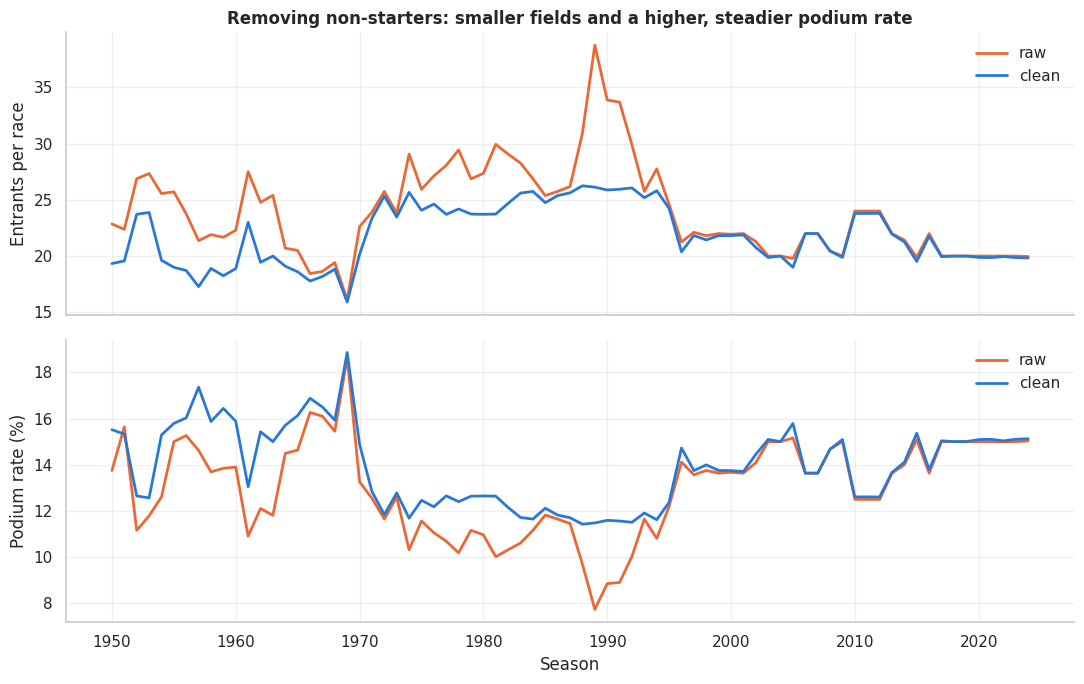

In [75]:
# --- Plot: entrants per race and podium rate, raw vs clean -----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, col, label in [(axes[0], "entrants_per_race", "Entrants per race"),
                       (axes[1], "podium_rate_%", "Podium rate (%)")]:
    ax.plot(context_raw.index, context_raw[col], color=PALETTE[1], label="raw")
    ax.plot(context_clean.index, context_clean[col], color=PALETTE[0], label="clean")
    ax.set_ylabel(label)
    ax.legend(frameon=False)
axes[0].set_title("Removing non-starters: smaller fields and a higher, steadier podium rate")
axes[1].set_xlabel("Season")
plt.tight_layout()
plt.show()

**Impact:** after removing non-starters, each race only counts drivers who actually started, so field size and podium rate
become comparable across eras. The gap between the raw and clean lines is largest in the late 1980s / early 1990s
(pre-qualifying and non-qualifiers), exactly where 1.7 found most `F` rows. Podiums remain the minority class.

## 3.7 Consistency checks: before vs after

In [76]:
# --- Re-run the 1.9 checks on the clean tables ------------------------------------------------------
consistency_compare = consistency_raw.merge(consistency_checks(clean), on=["table", "check"],
                                            suffixes=("_raw", "_clean"))
consistency_compare

,table,check,violations_raw,violations_clean
0,races,season year differs from year of race date,0,0
1,races,"duplicate (year, round)",0,0
2,results,driver age on race day outside 17-60,0,0
3,results,negative points or laps,0,0
4,results,classified position differs from positionOrder,13,13
5,results,rows sharing a positionOrder with another driver,228,0
6,results,races without exactly 3 podium rows,18,0
7,results,rows sharing a grid slot (> 0) with another dr...,377,148
8,qualifying,duplicate qualifying position within a race,0,0
9,qualifying,qualifying rows without a results row,0,76


**Impact:** the shared-drive problems are gone: no tied `positionOrder`, and every race has exactly 3 podium rows.
What remains is expected and documented:
- the single vacant-place race (`position` ≠ `positionOrder`), a property of the official result;
- shared grid slots, which this dataset cannot resolve;
- **qualifying rows without a results row increase**, because `qualifying` still lists drivers who failed to qualify while 2.6 removed them
  from `results`. This is harmless: features are joined from `results`, so those rows are never used.

## 3.8 Summary: finding → decision

| # | Finding (evidence) | Decision (step) |
|---|---|---|
| 1 | `\N` sentinels in 6 tables; missingness is outcome-, era- or structure-based (1.1, 1.2) | `\N` → `NaN` everywhere, no imputation in cleaning, meanings documented (2.2, handover) |
| 2 | Qualifying / lap / pit tables only exist for recent decades (1.3) | Handed over to features: fallback to `grid` or restricted window |
| 3 | Dates, clock times, durations and numbers stored as text, durations in 5 formats (1.4) | Typed; durations parsed to seconds and **validated against `milliseconds`** (2.3) |
| 4 | `results.time` mixes total time and gaps (1.4) | Left as text; `milliseconds` is the numeric version (2.3) |
| 5 | Near-empty columns such as `constructor_results.status` (1.1) | Dropped at ≥ 99 % missing; sprint columns kept as structural (2.4) |
| 6 | Key audit (1.6) | PK/FK re-checked after typing, problems fixed and logged (2.5) |
| 7 | `F`/`W` rows never started; `grid = 0` mixes non-starters and pit-lane starts; Indy 500 is a separate event (1.7) | Non-starters and Indy 500 removed; pit-lane starts kept (2.6) |
| 8 | Duplicate `(raceId, driverId)` pairs from shared drives; "non-zero grid" resolves none; "best finish" selects on the target (1.5, 2.7) | Keep earliest entry (lowest `resultId`) = car the driver started in; grain proven unique (2.7) |
| 9 | Values are mostly consistent; shared drives also create tied finishing positions via relief drivers; one vacant-place race; a few shared grid slots (1.9) | Relief drivers removed, 3 podium rows per race guaranteed (2.7b); remaining quirks documented (3.7) |
| 10 | Raw files must stay unchanged | `assert_raw_unchanged()` passes (2.8) |

# 4. Data-Engineering Questions

All three questions are answered on the **cleaned** tables (`clean`), so they inherit the cleaning decisions:
one row per driver who took the start, no Indianapolis 500, no shared-drive or relief-driver duplicates.

Each answer states the tables joined (multi-hop), the **grain** (what one row means), how **missingness** was handled,
and, where relevant, the **pre-race cutoff**. These are descriptive analyses of history, not features: they may use
race outcomes freely, because nothing here is used to make a prediction.

## 4.1 Q1: Which circuits convert a front-row start into a podium most often, and does the ranking change after 2014?

**Approach**
- **Joins:** `results` → `races` (season, circuit) → `circuits` (circuit name), plus `qualifying` on `(raceId, driverId)` for the qualifying position.
- **Two definitions of "front row"**, as the question requires:
  - by **grid**: `grid` is 1 or 2 (where the car actually started, after penalties);
  - by **qualifying**: qualifying `position` is 1 or 2 (before penalties).
- **Conversion rate** = podiums ÷ front-row starts, per circuit and era (**pre-2014** vs **2014+**).
- **Sample:** only races that have qualifying data, so both definitions are measured on exactly the same races (1.3 showed qualifying
  starts in the mid-1990s). Circuits need at least `MIN_FRONT_ROW` front-row starts in an era to be ranked, to avoid rankings driven by 2–3 races.

In [77]:
# --- Q1 base table: one row per driver-race, with circuit and qualifying position ----------------
q1 = (clean["results"][["raceId", "driverId", "grid", "positionOrder"]]
      .merge(clean["races"][["raceId", "year", "circuitId"]], on="raceId")
      .merge(clean["circuits"][["circuitId", "name"]].rename(columns={"name": "circuit"}), on="circuitId")
      .merge(clean["qualifying"][["raceId", "driverId", "position"]].rename(columns={"position": "quali_pos"}),
             on=["raceId", "driverId"], how="left"))

# Keep only races that have qualifying data, so both definitions use the same races.
q1 = q1[q1["raceId"].isin(clean["qualifying"]["raceId"])].copy()
q1["podium"] = q1["positionOrder"] <= PODIUM_CUTOFF
q1["era"] = np.where(q1["year"] >= HYBRID_ERA[0], "2014+", "pre-2014")
q1["front_row_grid"] = q1["grid"].isin([1, 2])
q1["front_row_quali"] = q1["quali_pos"].isin([1, 2])

assert not q1.duplicated(["raceId", "driverId"]).any()        # grain check
print(f"Rows: {len(q1):,} | races: {q1['raceId'].nunique()} | seasons {q1['year'].min()}-{q1['year'].max()}")
print(q1.groupby("era")["raceId"].nunique().rename("races").to_string())

Rows: 10,439 | races: 494 | seasons 1994-2024
era
2014+       228
pre-2014    266


In [78]:
# --- Grid vs qualifying: do the two definitions disagree? --------------------------------------------
# Rows where they disagree are drivers moved by penalties (or pit-lane starts) or promoted
# because someone ahead was penalised.
groups = {
    "front row in both":                         q1["front_row_grid"] & q1["front_row_quali"],
    "qualified front row, started further back": ~q1["front_row_grid"] & q1["front_row_quali"],
    "started front row, qualified lower":        q1["front_row_grid"] & ~q1["front_row_quali"],
}
grid_vs_quali = pd.DataFrame({
    "rows": {k: int(m.sum()) for k, m in groups.items()},
    "podium_rate_%": {k: 100 * q1.loc[m, "podium"].mean() for k, m in groups.items()},
}).round(1)
grid_vs_quali

,rows,podium_rate_%
front row in both,947,70.6
"qualified front row, started further back",37,29.7
"started front row, qualified lower",36,63.9


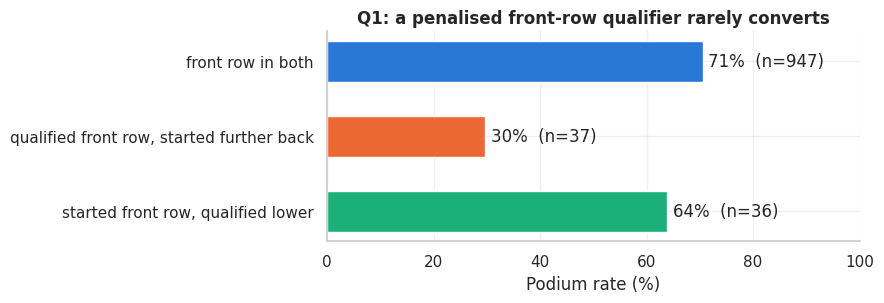

In [79]:
# --- Plot: podium rate by front-row group --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(grid_vs_quali.index, grid_vs_quali["podium_rate_%"], color=[PALETTE[0], PALETTE[1], PALETTE[2]], height=0.55)
for i, (rate, n) in enumerate(zip(grid_vs_quali["podium_rate_%"], grid_vs_quali["rows"])):
    ax.text(rate + 1, i, f"{rate:.0f}%  (n={n})", va="center")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Podium rate (%)")
ax.set_title("Q1: a penalised front-row qualifier rarely converts")
plt.tight_layout()
plt.show()

In [80]:
# --- Conversion rate per circuit and era, for both definitions -------------------------------------------
MIN_FRONT_ROW = 10   # minimum front-row starts per circuit per era (= at least 5 races)

def conversion_by_circuit(df, flag):
    g = (df[df[flag]].groupby(["circuit", "era"])["podium"]
         .agg(starts="size", podiums="sum").unstack("era"))
    rate = 100 * g["podiums"] / g["starts"]
    out = pd.DataFrame({
        "starts_pre": g[("starts", "pre-2014")], "rate_pre_%": rate["pre-2014"],
        "starts_2014+": g[("starts", "2014+")], "rate_2014+_%": rate["2014+"],
    })
    ok = (out["starts_pre"] >= MIN_FRONT_ROW) & (out["starts_2014+"] >= MIN_FRONT_ROW)
    out = out[ok].copy()
    out["rank_pre"] = out["rate_pre_%"].rank(ascending=False, method="min").astype(int)
    out["rank_2014+"] = out["rate_2014+_%"].rank(ascending=False, method="min").astype(int)
    return out.sort_values("rate_2014+_%", ascending=False)

conv_grid = conversion_by_circuit(q1, "front_row_grid")
conv_quali = conversion_by_circuit(q1, "front_row_quali")
print(f"Circuits with >= {MIN_FRONT_ROW} front-row starts in both eras: {len(conv_grid)}")
conv_grid.round(1)

Circuits with >= 10 front-row starts in both eras: 14


,starts_pre,rate_pre_%,starts_2014+,rate_2014+_%,rank_pre,rank_2014+
circuit,,,,,,
Circuit de Monaco,28.0,71.4,19.0,89.5,2,1
Suzuka Circuit,26.0,76.9,18.0,88.9,1,2
Yas Marina Circuit,10.0,60.0,22.0,86.4,9,3
Circuit de Spa-Francorchamps,24.0,54.2,22.0,81.8,13,4
Circuit de Barcelona-Catalunya,30.0,66.7,22.0,81.8,5,4
Autódromo José Carlos Pace,34.0,58.8,19.0,78.9,10,6
Shanghai International Circuit,20.0,65.0,14.0,78.6,7,7
Circuit Gilles Villeneuve,26.0,57.7,18.0,77.8,12,8
Silverstone Circuit,32.0,62.5,24.0,75.0,8,9


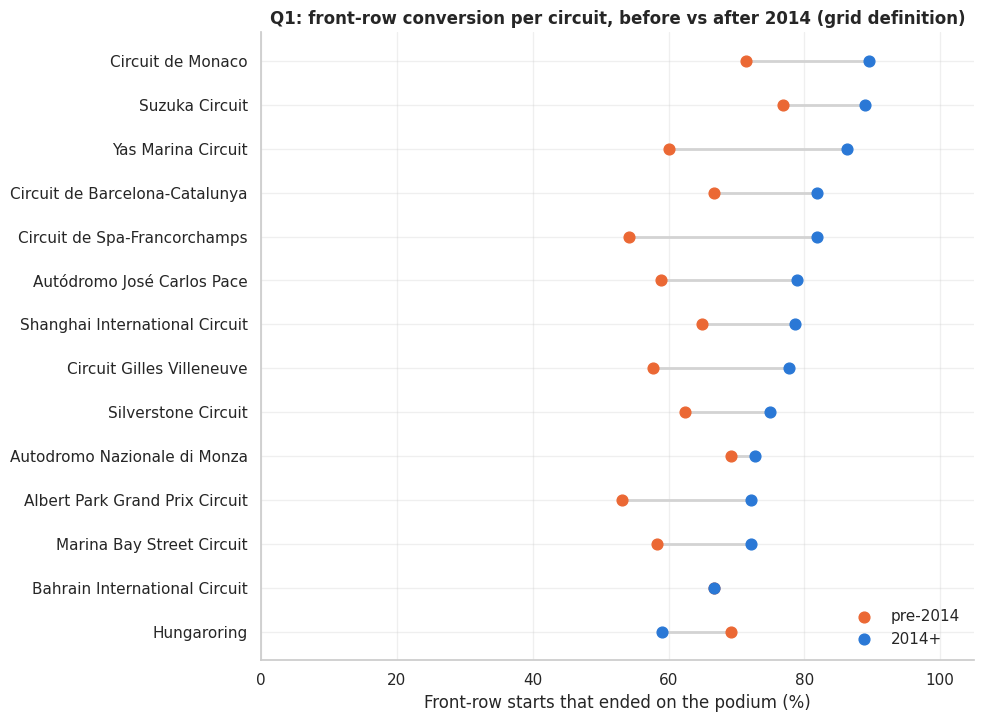

In [81]:
# --- Plot: conversion before vs after 2014, per circuit (grid definition) ---------------------------------
d = conv_grid.sort_values("rate_2014+_%")
y = np.arange(len(d))
fig, ax = plt.subplots(figsize=(10, 0.42 * len(d) + 1.5))
ax.hlines(y, d["rate_pre_%"], d["rate_2014+_%"], color="lightgrey", lw=2, zorder=1)
ax.scatter(d["rate_pre_%"], y, color=PALETTE[1], s=60, label="pre-2014", zorder=2)
ax.scatter(d["rate_2014+_%"], y, color=PALETTE[0], s=60, label="2014+", zorder=3)
ax.set_yticks(y, d.index)
ax.set_xlim(0, 105)
ax.set_xlabel("Front-row starts that ended on the podium (%)")
ax.set_title("Q1: front-row conversion per circuit, before vs after 2014 (grid definition)")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [82]:
# --- Does the ranking change? Rank correlation between eras --------------------------------------------------
# Spearman correlation compares the two rankings: +1 = identical order, 0 = unrelated order.
from scipy.stats import spearmanr

rows = []
for label, conv, flag in [("grid", conv_grid, "front_row_grid"), ("qualifying", conv_quali, "front_row_quali")]:
    rho, p = spearmanr(conv["rate_pre_%"], conv["rate_2014+_%"])
    overall = q1[q1[flag]].groupby("era")["podium"].mean() * 100
    rows.append({"definition": label, "circuits": len(conv),
                 "overall_pre_%": overall["pre-2014"], "overall_2014+_%": overall["2014+"],
                 "spearman_rho": rho, "p_value": p,
                 "top3_pre": ", ".join(conv.sort_values("rate_pre_%", ascending=False).index[:3]),
                 "top3_2014+": ", ".join(conv.index[:3])})
q1_summary = pd.DataFrame(rows).round(3)
q1_summary.T

,0,1
definition,grid,qualifying
circuits,14,14
overall_pre_%,65.472,64.906
overall_2014+_%,76.159,74.009
spearman_rho,0.206,0.14
p_value,0.479,0.633
top3_pre,"Suzuka Circuit, Circuit de Monaco, Hungaroring","Suzuka Circuit, Shanghai International Circuit..."
top3_2014+,"Circuit de Monaco, Suzuka Circuit, Yas Marina ...","Circuit de Monaco, Suzuka Circuit, Circuit de ..."


### Answer Q1
*(Numbers below are from our run; they are printed by the cells above.)*

- **Best converters since 2014:** street and high-downforce tracks where overtaking is hard (e.g. **Monaco**, **Suzuka**, Yas Marina, Spa, Barcelona
  in our run) convert a front-row start into a podium in roughly 80–90 % of cases.
- **The ranking changes after 2014.** The rank correlation between the two eras is weak (Spearman ρ ≈ 0.1–0.2, not significant), so a circuit's
  pre-2014 conversion says little about its 2014+ conversion. At the same time, conversion **rose overall** (about 66 % → 76 % by grid), consistent with
  more reliable cars and the dominance of one or two teams in the hybrid era.
- **Grid vs qualifying matters.** Drivers who *qualified* on the front row but *started* further back (penalties, pit-lane starts) reached the podium in only
  about 30 % of cases, while drivers promoted onto the front row converted at a rate close to regular front-row starters. Overall conversion is
  almost the same under both definitions (they disagree for only a few dozen rows), but individual circuit ranks can shift, especially before 2014
  where samples per circuit are small, which is why both rankings are reported.

**Grain:** one row per driver-race; front-row rows are 2 per race. **Missingness:** races without qualifying data are excluded so both definitions use the
same races; circuits with fewer than `MIN_FRONT_ROW` front-row starts in an era are not ranked (small samples, e.g. circuits used in one era only).
**Cutoff:** grid and qualifying position are both pre-race information, which is why the grid/qualifying distinction also matters for the model.

## 4.2 Q2: Do drivers podium more often at home, after controlling for starting position?

**Approach**
- **Joins:** `results` → `drivers` (nationality) and `results` → `races` → `circuits` (country): a home race is one where the circuit's country matches the
  driver's nationality.
- **Mapping:** nationality ("British") and country ("UK") use different words, so an explicit mapping table is needed. Dual nationalities
  ("American-Italian") count as home in both countries; text is stripped of stray spaces and "United States"/"USA" are unified.
- **Controlling for starting position:** drivers are compared **within grid bands** (1, 2–3, 4–6, 7–10, 11+). Pit-lane starts (`grid = 0`) have no band and are excluded.
- **Test:** the **Cochran–Mantel–Haenszel (CMH)** method combines the home-vs-away comparison of every band into one **odds ratio**
  (> 1 = home advantage, < 1 = disadvantage, 1 = no effect), with a 95 % confidence interval and a p-value. It is written out below with
  `numpy`/`scipy` so every step is visible.

In [83]:
# --- Nationality -> country mapping ---------------------------------------------------------------------
# Each nationality maps to the circuit country (or countries) that count as "home".
NATIONALITY_TO_COUNTRIES = {
    "American": ["USA"], "American-Italian": ["USA", "Italy"], "Argentine": ["Argentina"],
    "Argentinian": ["Argentina"], "Argentine-Italian": ["Argentina", "Italy"], "Australian": ["Australia"],
    "Austrian": ["Austria"], "Belgian": ["Belgium"], "Brazilian": ["Brazil"], "British": ["UK"],
    "Canadian": ["Canada"], "Chilean": ["Chile"], "Chinese": ["China"], "Colombian": ["Colombia"],
    "Czech": ["Czech Republic"], "Danish": ["Denmark"], "Dutch": ["Netherlands"], "East German": ["Germany"],
    "Finnish": ["Finland"], "French": ["France"], "German": ["Germany"], "Hungarian": ["Hungary"],
    "Indian": ["India"], "Indonesian": ["Indonesia"], "Irish": ["Ireland"], "Italian": ["Italy"],
    "Japanese": ["Japan"], "Liechtensteiner": ["Liechtenstein"], "Malaysian": ["Malaysia"], "Mexican": ["Mexico"],
    "Monegasque": ["Monaco"], "New Zealander": ["New Zealand"], "Polish": ["Poland"], "Portuguese": ["Portugal"],
    "Rhodesian": ["Rhodesia"], "Russian": ["Russia"], "South African": ["South Africa"], "Spanish": ["Spain"],
    "Swedish": ["Sweden"], "Swiss": ["Switzerland"], "Thai": ["Thailand"], "Uruguayan": ["Uruguay"],
    "Venezuelan": ["Venezuela"],
}
CIRCUIT_COUNTRY_ALIASES = {"United States": "USA"}

nationalities = set(clean["drivers"]["nationality"].str.strip())
unmapped = sorted(nationalities - set(NATIONALITY_TO_COUNTRIES))
print("Unmapped nationalities (treated as never home):", unmapped or "none ✔")

circuit_countries = set(clean["circuits"]["country"].str.strip().replace(CIRCUIT_COUNTRY_ALIASES))
mapped_countries = {c for cs in NATIONALITY_TO_COUNTRIES.values() for c in cs}
print("Circuit countries with no driver nationality (always 'away'):", sorted(circuit_countries - mapped_countries))

Unmapped nationalities (treated as never home): none ✔
Circuit countries with no driver nationality (always 'away'): ['Azerbaijan', 'Bahrain', 'Korea', 'Morocco', 'Qatar', 'Saudi Arabia', 'Singapore', 'Turkey', 'UAE']


In [84]:
# --- Q2 base table: one row per driver-race with a home flag and a grid band -------------------------------
q2 = (clean["results"][["raceId", "driverId", "grid", "positionOrder"]]
      .merge(clean["races"][["raceId", "year", "circuitId"]], on="raceId")
      .merge(clean["circuits"][["circuitId", "country"]], on="circuitId")
      .merge(clean["drivers"][["driverId", "nationality"]], on="driverId"))
q2["circuit_country"] = q2["country"].str.strip().replace(CIRCUIT_COUNTRY_ALIASES)
q2["home"] = [cc in NATIONALITY_TO_COUNTRIES.get(nat.strip(), [])
              for nat, cc in zip(q2["nationality"], q2["circuit_country"])]
q2["podium"] = q2["positionOrder"] <= PODIUM_CUTOFF

pit_lane = int((q2["grid"] == 0).sum())
q2 = q2[q2["grid"] > 0].copy()
q2["grid_band"] = pd.cut(q2["grid"], [0, 1, 3, 6, 10, np.inf], labels=["1", "2-3", "4-6", "7-10", "11+"])

assert not q2.duplicated(["raceId", "driverId"]).any()          # grain check
print(f"Rows: {len(q2):,} (excluded {pit_lane} pit-lane starts) | home rows: {int(q2['home'].sum()):,} ({q2['home'].mean():.1%})")

Rows: 24,483 (excluded 87 pit-lane starts) | home rows: 1,920 (7.8%)


In [85]:
# --- Why controlling for grid is needed: home and away drivers start from different places ------------------
start_mix = pd.crosstab(q2["grid_band"], q2["home"].map({True: "home", False: "away"}), normalize="columns") * 100
print("Mean grid: home", round(q2.loc[q2["home"], "grid"].mean(), 1), "| away", round(q2.loc[~q2["home"], "grid"].mean(), 1))
start_mix.round(1).rename_axis("grid band (% of starts)")

Mean grid: home 12.7 | away 11.7


home,away,home
grid band (% of starts),,
1,4.6,4.2
2-3,9.2,7.8
4-6,13.8,11.7
7-10,18.1,17.3
11+,54.3,59.1


In [86]:
# --- Podium rate by grid band, home vs away -------------------------------------------------------------------
by_band = (q2.groupby(["grid_band", "home"], observed=True)["podium"]
           .agg(starts="size", rate="mean").unstack("home"))
by_band.columns = [f"{m}_{'home' if h else 'away'}" for m, h in by_band.columns]
by_band[["rate_away", "rate_home"]] *= 100
by_band = by_band[["starts_away", "rate_away", "starts_home", "rate_home"]]
by_band.round(1)

,starts_away,rate_away,starts_home,rate_home
grid_band,,,,
1,1030,64.7,81,60.5
2-3,2070,51.1,149,53.7
4-6,3109,26.0,224,26.8
7-10,4095,9.3,332,7.2
11+,12259,1.7,1134,1.1


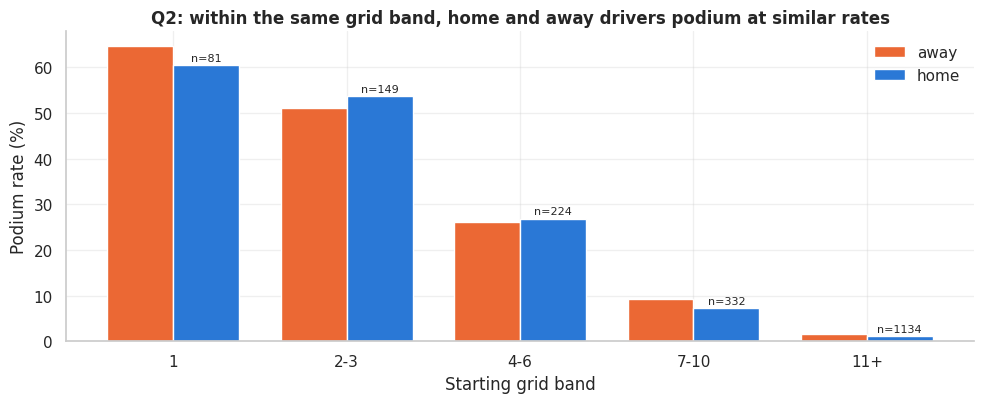

In [87]:
# --- Plot: podium rate by grid band, home vs away -------------------------------------------------------------
x = np.arange(len(by_band))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(x - w / 2, by_band["rate_away"], w, color=PALETTE[1], label="away")
ax.bar(x + w / 2, by_band["rate_home"], w, color=PALETTE[0], label="home")
for i, n in enumerate(by_band["starts_home"]):
    ax.text(i + w / 2, by_band["rate_home"].iloc[i] + 1, f"n={int(n)}", ha="center", fontsize=8)
ax.set_xticks(x, by_band.index)
ax.set_xlabel("Starting grid band")
ax.set_ylabel("Podium rate (%)")
ax.set_title("Q2: within the same grid band, home and away drivers podium at similar rates")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [88]:
# --- Cochran-Mantel-Haenszel: one odds ratio across all strata ---------------------------------------------
# For each stratum (e.g. a grid band) build the 2x2 table:
#              podium   no podium
#   home         a          b
#   away         c          d
# The CMH odds ratio is a weighted average of the strata's odds ratios; the CI uses the
# Robins-Breslow-Greenland variance; the test is the CMH chi-square with continuity correction.
from scipy.stats import chi2

def cmh(df, strata, exposure="home", outcome="podium"):
    R = S = PR = PS_QR = QS = 0.0
    sum_a = sum_e = sum_v = 0.0
    for _, g in df.groupby(strata, observed=True):
        a = int((g[exposure] & g[outcome]).sum());  b = int((g[exposure] & ~g[outcome]).sum())
        c = int((~g[exposure] & g[outcome]).sum()); d = int((~g[exposure] & ~g[outcome]).sum())
        n = a + b + c + d
        if n < 2 or a + b == 0 or c + d == 0:
            continue                                   # stratum has no home or no away rows
        r, s = a * d / n, b * c / n
        p, q = (a + d) / n, (b + c) / n
        R += r; S += s; PR += p * r; PS_QR += p * s + q * r; QS += q * s
        sum_a += a
        sum_e += (a + b) * (a + c) / n
        sum_v += (a + b) * (c + d) * (a + c) * (b + d) / (n * n * (n - 1))
    odds_ratio = R / S
    se_log = np.sqrt(PR / (2 * R ** 2) + PS_QR / (2 * R * S) + QS / (2 * S ** 2))
    stat = (abs(sum_a - sum_e) - 0.5) ** 2 / sum_v
    return {"odds_ratio": odds_ratio,
            "ci_low": np.exp(np.log(odds_ratio) - 1.96 * se_log),
            "ci_high": np.exp(np.log(odds_ratio) + 1.96 * se_log),
            "p_value": chi2.sf(stat, df=1)}

In [89]:
# --- Apply: no control, control for grid band, control for grid band and decade -----------------------------
q2["decade"] = q2["year"] // 10 * 10
q2["all"] = "all"
q2_results = pd.DataFrame({
    "no control (crude)":       cmh(q2, "all"),
    "controlling grid band":    cmh(q2, "grid_band"),
    "grid band + decade":       cmh(q2, ["grid_band", "decade"]),
}).T
q2_results.round(3)

,odds_ratio,ci_low,ci_high,p_value
no control (crude),0.828,0.717,0.957,0.011
controlling grid band,0.922,0.776,1.096,0.386
grid band + decade,0.894,0.751,1.064,0.228


### Answer Q2
*(Numbers below are from our run; they are printed by the cells above.)*

**No: there is no evidence of a home advantage once starting position is taken into account.**

- Without any control, home drivers even look slightly *worse* (crude odds ratio below 1). The reason is visible in the start-position table:
  home drivers start further back on average, because many home entries, especially in the 1950s–70s, were **local one-off drivers** in
  uncompetitive cars.
- Comparing drivers **within the same grid band** removes that effect: the CMH odds ratio moves close to 1 (≈ 0.9 in our run) and its 95 % confidence
  interval **includes 1**, with a p-value well above 0.05. Adding the decade as a second control (to account for era differences) gives the same conclusion.
- In the plot, the home and away bars are close in every band; the small differences go in both directions and have small home samples (see `n`).

**Grain:** one row per driver-race (starters only). **Missingness:** no missing nationalities or countries; pit-lane starts (`grid = 0`) are excluded because they
have no grid band; nationalities without an F1 circuit in their country simply never have a home race. The **Indianapolis 500** was already removed in 2.6, which
matters here: almost all its drivers were American racing in the USA and would have inflated "home" rows. **Cutoff:** both nationality and grid are known before the
race, so a home flag is a valid feature candidate, but this analysis suggests it adds little once grid is known.

## 4.3 Q3: Which constructors have the highest mechanical-retirement rate in 2014–2021 vs 2022–2024?

**Approach**
- **Joins:** `results` → `status` (why the race ended) → `constructors` (team name), and `results` → `races` (season → era).
- **Classifying the status values:** every status is put into one category. A **mechanical retirement** is a start that ended because a **car component
  failed** (engine, gearbox, brakes, hydraulics, power unit, etc.). Excluded, as the brief says: crashes and damage, driver causes (illness, injury, stalling),
  and regulatory decisions (disqualified, excluded, withdrawn). The full mapping is shown below.
- **Rate** = mechanical retirements ÷ **race starts** for that constructor in that era. After 2.6, every row in `results` is a start.
- Constructors need at least `MIN_STARTS` starts in an era (about one full season with two cars) to be ranked.

In [90]:
# --- Status categories ------------------------------------------------------------------------------------------
# Finished = "Finished" or "+N Laps". Explicit lists for the non-mechanical categories;
# every other status names a failed car component and counts as mechanical.
ACCIDENT_DAMAGE = {"Accident", "Collision", "Collision damage", "Spun off", "Damage", "Debris",
                   "Puncture", "Tyre puncture", "Fatal accident"}
DRIVER = {"Physical", "Injured", "Injury", "Driver unwell", "Eye injury", "Illness", "Stalled"}
REGULATORY = {"Disqualified", "Excluded", "Withdrew", "Not classified", "107% Rule", "Did not qualify",
              "Did not prequalify", "Safety concerns", "Safety", "Not restarted", "Underweight"}
UNSPECIFIED = {"Retired", "Out of fuel", "Refuelling", "Fuel rig", "Handling"}

def status_category(status):
    s = str(status).strip()
    if s == "Finished" or s.startswith("+"):
        return "finished"
    if s in ACCIDENT_DAMAGE: return "accident / damage"
    if s in DRIVER:          return "driver"
    if s in REGULATORY:      return "regulatory"
    if s in UNSPECIFIED:     return "unspecified / other"
    return "mechanical"

status_map = clean["status"].assign(category=lambda d: d["status"].map(status_category))
status_map["category"].value_counts().to_frame("status values")

,status values
category,
mechanical,73
finished,34
regulatory,11
accident / damage,9
driver,7
unspecified / other,5


In [91]:
# --- Q3 base table: starts in 2014-2024 with status category and team ---------------------------------------------
q3 = (clean["results"][["raceId", "driverId", "constructorId", "statusId"]]
      .merge(clean["races"][["raceId", "year"]], on="raceId")
      .merge(status_map[["statusId", "status", "category"]], on="statusId", how="left")
      .merge(clean["constructors"][["constructorId", "name"]].rename(columns={"name": "constructor"}), on="constructorId"))
q3 = q3[q3["year"].between(HYBRID_ERA[0], GROUND_EFFECT_ERA[1])].copy()
q3["era"] = np.where(q3["year"] <= HYBRID_ERA[1],
                     f"{HYBRID_ERA[0]}-{HYBRID_ERA[1]}", f"{GROUND_EFFECT_ERA[0]}-{GROUND_EFFECT_ERA[1]}")

assert q3["category"].notna().all()                              # every status was classified
assert not q3.duplicated(["raceId", "driverId"]).any()           # grain check
print(f"Starts: {len(q3):,}")
pd.crosstab(q3["category"], q3["era"], margins=True)

Starts: 4,598


era,2014-2021,2022-2024,All
category,,,
accident / damage,226,89,315
driver,1,1,2
finished,2660,1165,3825
mechanical,311,80,391
regulatory,10,5,15
unspecified / other,38,12,50
All,3246,1352,4598


In [92]:
# --- The mapping as it applies to these seasons (documented, as the brief asks) -------------------------------------
(q3.groupby(["category", "status"]).size().rename("starts").reset_index()
   .sort_values(["category", "starts"], ascending=[True, False])
   .set_index(["category", "status"]))

starts
category            status                  
accident / damage   Collision            150
                    Accident              85
                    Collision damage      59
                    Spun off              11
                    Puncture               7
...                                      ...
regulatory          Disqualified          11
                    Withdrew               3
                    Excluded               1
unspecified / other Retired               49
                    Out of fuel            1

[65 rows x 1 columns]

In [93]:
# --- Mechanical-retirement rate per constructor and era --------------------------------------------------------------
MIN_STARTS = 40   # about one full season with two cars

q3_rates = (q3.groupby(["era", "constructor"])
              .agg(starts=("category", "size"),
                   mechanical=("category", lambda s: (s == "mechanical").sum()),
                   unspecified=("category", lambda s: (s == "unspecified / other").sum()))
              .reset_index())
q3_rates["mech_rate_%"] = 100 * q3_rates["mechanical"] / q3_rates["starts"]
# Sensitivity: upper bound if every unspecified retirement ("Retired", ...) was mechanical.
q3_rates["upper_bound_%"] = 100 * (q3_rates["mechanical"] + q3_rates["unspecified"]) / q3_rates["starts"]
q3_rates = q3_rates[q3_rates["starts"] >= MIN_STARTS].sort_values(["era", "mech_rate_%"], ascending=[True, False])
q3_rates.round(1).set_index(["era", "constructor"])

starts  mechanical  unspecified  mech_rate_%  upper_bound_%
era       constructor                                                                
2014-2021 Lotus F1            75          15            3         20.0           24.0
          Toro Rosso         242          39            4         16.1           17.8
          Renault            199          28            3         14.1           15.6
          McLaren            316          43            5         13.6           15.2
          Sauber             199          22            4         11.1           13.1
          Red Bull           318          34            1         10.7           11.0
          Haas F1 Team       241          23            6          9.5           12.0
          AlphaTauri          77           7            1          9.1           10.4
          Alpine F1 Team      44           4            0          9.1            9.1
          Racing Point        75           6            0          8.0            8.0
          Williams           319          24            4          7.5            8.8
          Force India        198          13            0          6.6            6.6
          Ferrari            318          20            0          6.3            6.3
          Manor Marussia      77           4            2          5.2            7.8
          Alfa Romeo         120           5            0          4.2            4.2
          Mercedes           320          13            1          4.1            4.4
          Aston Martin        44           1            1          2.3            4.5
2022-2024 Alfa Romeo          88          11            0         12.5           12.5
          Alpine F1 Team     135          14            0         10.4           10.4
          AlphaTauri          88           7            0          8.0            8.0
          Williams           134           8            3          6.0            8.2
          Aston Martin       134           7            1          5.2            6.0
          Ferrari            134           7            2          5.2            6.7
          Haas F1 Team       135           7            0          5.2            5.2
          Mercedes           136           6            0          4.4            4.4
          RB F1 Team          48           2            3          4.2           10.4
          McLaren            136           5            0          3.7            3.7
          Red Bull           136           5            1          3.7            4.4
          Sauber              48           1            2          2.1            6.2

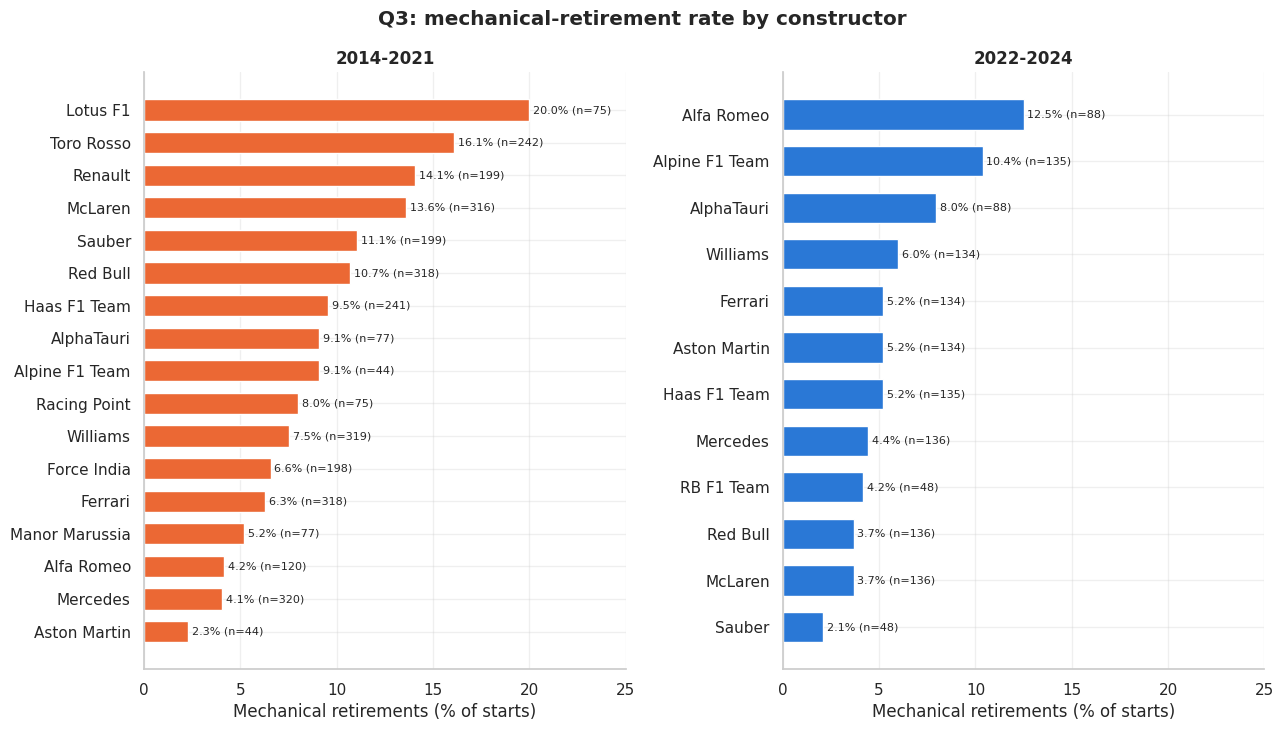

In [94]:
# --- Plot: ranking per era (one panel per era, same scale) ------------------------------------------------------------
eras = sorted(q3_rates["era"].unique())
xmax = q3_rates["mech_rate_%"].max() * 1.25
fig, axes = plt.subplots(1, len(eras), figsize=(13, 0.32 * q3_rates.groupby("era").size().max() + 2))
for ax, era, color in zip(axes, eras, [PALETTE[1], PALETTE[0]]):
    d = q3_rates[q3_rates["era"] == era].sort_values("mech_rate_%")
    ax.barh(d["constructor"], d["mech_rate_%"], color=color, height=0.65)
    for i, (v, n) in enumerate(zip(d["mech_rate_%"], d["starts"])):
        ax.text(v + 0.2, i, f"{v:.1f}% (n={n})", va="center", fontsize=8)
    ax.set_xlim(0, xmax)
    ax.set_title(era)
    ax.set_xlabel("Mechanical retirements (% of starts)")
fig.suptitle("Q3: mechanical-retirement rate by constructor", fontweight="bold")
plt.tight_layout()
plt.show()

In [95]:
# --- Overall reliability per era and the top 3 per era ------------------------------------------------------------------
overall = q3.groupby("era")["category"].apply(lambda s: 100 * (s == "mechanical").mean()).rename("mech_rate_%")
top3 = q3_rates.groupby("era").head(3).groupby("era")["constructor"].apply(", ".join).rename("top 3 (highest rate)")
pd.concat([overall.round(1), top3], axis=1)

,mech_rate_%,top 3 (highest rate)
era,,
2014-2021,9.6,"Lotus F1, Toro Rosso, Renault"
2022-2024,5.9,"Alfa Romeo, Alpine F1 Team, AlphaTauri"


### Answer Q3
*(Numbers below are from our run; they are printed by the cells above.)*

- **2014–2021 (hybrid era):** the highest mechanical-retirement rates belong to smaller or works teams struggling with the new power units,
  e.g. **Lotus F1**, **Toro Rosso**, **Renault** and **McLaren** (the McLaren-Honda years), at roughly 14–20 % of starts. **Mercedes**, the dominant team of the era,
  was among the most reliable (around 4 %).
- **2022–2024 (ground-effect era):** **Alfa Romeo** and **Alpine** have the highest rates (around 10–12 %), and the front-running teams (Red Bull, McLaren, Mercedes) are
  around 4 %.
- **Reliability improved overall:** the share of starts ending in a mechanical failure is clearly lower in 2022–2024 than in 2014–2021 (overall table above).

**Judgement calls (documented):** "Retired" without a stated cause, "Out of fuel" and similar are **not** counted as mechanical (the cause is unknown).
The `upper_bound_%` column shows the rate if they were: for most teams it changes little, but a team with several unexplained retirements
(e.g. RB in 2024) moves up noticeably, so its rank should be read with that caveat. Punctures are counted as damage (usually debris or contact),
while "Tyre", "Wheel" and "Wheel nut" failures count as mechanical (a component failed). Renamed teams (e.g. Toro Rosso → AlphaTauri → RB, Sauber → Alfa Romeo → Sauber)
are separate `constructorId`s in the data, so they appear separately.

**Grain:** one row per driver-race start; the rate is aggregated per constructor and era. **Missingness:** every status was classified (assertion above);
constructors with fewer than `MIN_STARTS` starts in an era are not ranked. **Cutoff:** `status` is post-race, so it is used here only for analysis; a team's
*past* reliability (e.g. mechanical DNF rate over previous races) is a valid, leakage-safe feature candidate.

## 4.4 Summary of the answers

| Question | Answer | Key evidence |
|---|---|---|
| Q1 Front-row conversion by circuit | Tracks where overtaking is hard (e.g. Monaco, Suzuka) convert most; the ranking changes substantially after 2014 (weak rank correlation) while conversion rises overall. Penalised front-row qualifiers rarely convert. | 4.1 dumbbell plot, Spearman table, grid-vs-qualifying plot |
| Q2 Home advantage | No significant home advantage after controlling for grid (CMH odds ratio ≈ 1, CI includes 1); the crude difference is explained by where home drivers start. | 4.2 grouped bar plot, CMH table |
| Q3 Mechanical retirements | 2014–2021: Lotus F1, Toro Rosso, Renault, McLaren highest; 2022–2024: Alfa Romeo, Alpine highest; overall reliability improved. | 4.3 ranking plot, rate table with sensitivity bound |

# 5. Feature Selection & Engineering

_Leakage-safe grid, qualifying, standings (shifted), form (past races only) and context features, each justified with evidence; full leakage audit table._

In [96]:
# TODO

# 6. Train / Validation / Test Split

_Temporal split: train ≤ 2019, validation 2020–2021, test ≥ 2022 — with justification._

In [97]:
# TODO

# 7. Pre-processing

_Imputation, scaling and encoding fit on training data only; effect on distributions; at least two preprocessing-order experiments._

In [98]:
# TODO

# 8. Predictive Modeling

_Baseline, at least two statistical ML models, shallow NN; ROC-AUC, PR-AUC, F1 on train/validation/test; thresholds and hyperparameters chosen on validation only._

In [99]:
# TODO

# 9. Feature-Group Ablation

_Remove one feature group at a time, retrain, and report the performance drop._

In [100]:
# TODO

# 10. Explainability (XAI)

_Global: permutation importance and SHAP. Local: SHAP waterfall and LIME. Importance is not causation._

In [101]:
# TODO

# 11. Inference Function

_Predict for a single driver-race record; demonstrated on a complete and a partially-missing record._

In [102]:
# TODO

# 12. Summary & Limitations

_Key results, chosen primary/secondary metric, and limitations (qualifying coverage drift, era sensitivity)._

In [103]:
# TODO

In [104]:
assert_raw_unchanged()  # final check: raw data was never modified

Raw tables unchanged ✔
